In [2]:
import os
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge, ElasticNet
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import xgboost as xgb
import lightgbm as lgb

In [3]:
import sys
sys.path.append("../..")

from regression import simple_regression, cross_gen, interaction_regression, huber_regression, decision_tree, random_forest, extra_trees, xgboost_model, lightgbm_model, gpr_matern, gpr_rational_quadratic, ann, predict_gpr_in_batches, predict_ann_in_batches

In [4]:
DATA_DIR = "/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/Feature_extraction/Non_fiducial_features/8sec_0overlap/data"

train_path = os.path.join(DATA_DIR, "DBP_MRMR_train.csv")
val_path   = os.path.join(DATA_DIR, "DBP_MRMR_val.csv")
test_path  = os.path.join(DATA_DIR, "DBP_MRMR_test.csv")

df_train = pd.read_csv(train_path)
df_val   = pd.read_csv(val_path)
df_test  = pd.read_csv(test_path)

print("Train:", df_train.shape)
print("Val:  ", df_val.shape)
print("Test: ", df_test.shape)

Train: (263103, 16)
Val:   (33223, 16)
Test:  (33347, 16)


In [5]:
TARGET = "DBP"

X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]

X_val = df_val.drop(columns=[TARGET])
y_val = df_val[TARGET]

X_test = df_test.drop(columns=[TARGET])
y_test = df_test[TARGET]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:  ", X_val.shape)
print("y_val:  ", y_val.shape)
print("X_test: ", X_test.shape)
print("y_test: ", y_test.shape)

X_train: (263103, 15)
y_train: (263103,)
X_val:   (33223, 15)
y_val:   (33223,)
X_test:  (33347, 15)
y_test:  (33347,)


In [6]:
VITAL_PATH = "/data1/yashvi_bhuva/BP_estimation_using_PPG/VitalDB/ML/non_fiducial_features/8sec_0overlap/data/DBP_MRMR_vitaldb.csv"
vital_test = pd.read_csv(VITAL_PATH)
print(vital_test.shape)
print(df_train.head())

(2928374, 17)
   ppg_mean  apg_kte_iqr  ppg_zero_crossing_rate  vpg_mean  \
0  3.272922    -0.548634                     0.0 -0.127401   
1  2.855088    -0.495748                     0.0  0.085049   
2  3.195013    -0.620325                     0.0 -2.313259   
3  3.061656    -0.503614                     0.0  2.014257   
4  3.338505    -0.519571                     0.0  0.634868   

   ppg_energy_variance  apg_zero_crossing_rate  ppg_kte_kurtosis  apg_mean  \
0             0.983130               -0.339146         -0.289416 -1.422879   
1             1.032805               -0.186419         -0.256478  1.402739   
2             0.636401               -0.339146         -0.281906 -0.413076   
3             0.921181                0.959027         -0.282573  0.555521   
4             1.145072                0.500849         -0.229603 -1.595798   

   apg_median  vpg_median  apg_energy_variance   vpg_iqr   ppg_iqr  \
0   -1.598747   -2.880214            -0.017705  1.824971  0.766796   
1   

In [7]:
X_test_vital = vital_test.drop(columns=[TARGET, "case_id"])
y_test_vital = vital_test[TARGET]

In [8]:
X_dev = pd.concat([X_train, X_val], axis=0)
y_dev = pd.concat([y_train, y_val], axis=0)

In [9]:
print("DBP min:", y_train.min())
print("DBP max:", y_train.max())
print("DBP mean:", y_train.mean())
print("DBP std:", y_train.std())

print("DBP > 80:", np.sum(y_train > 80))
print("DBP > 90:", np.sum(y_train > 90))
print("DBP > 100:", np.sum(y_train > 100))

DBP min: 50.0
DBP max: 149.80486780343182
DBP mean: 66.41287378707464
DBP std: 10.878506659869677
DBP > 80: 29106
DBP > 90: 8829
DBP > 100: 2904


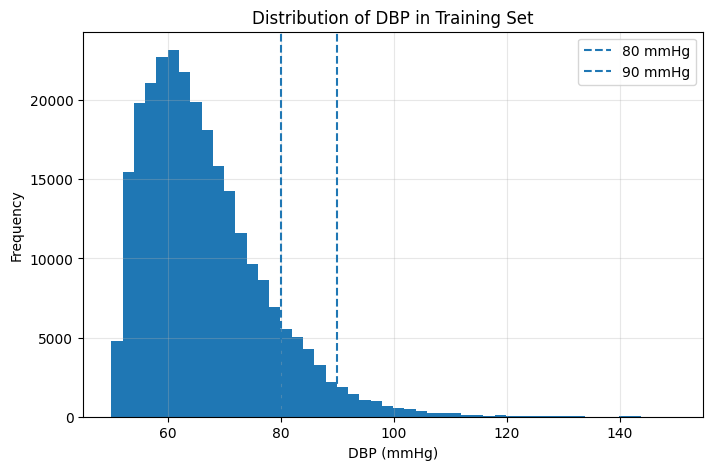

In [10]:
from matplotlib import pyplot as plt
plt.figure(figsize=(8,5))

plt.hist(y_train, bins=50)

plt.axvline(80, linestyle="--", label="80 mmHg")
plt.axvline(90, linestyle="--", label="90 mmHg")

plt.xlabel("DBP (mmHg)")
plt.ylabel("Frequency")
plt.title("Distribution of DBP in Training Set")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## SIMPLE LINEAR REGRESSION ##

Simple Linear Regression
------------------------
Target: DBP
RMSE: 10.7693
MSE : 115.9785
R²  : 0.0716
MAE : 8.4711


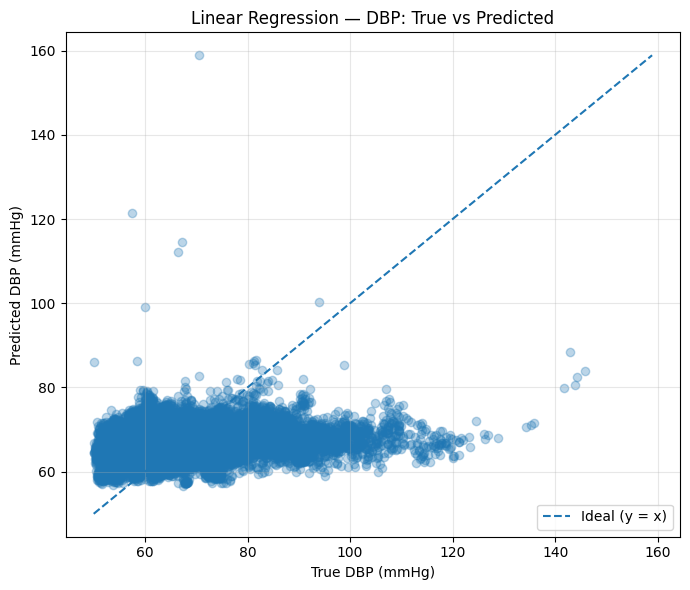

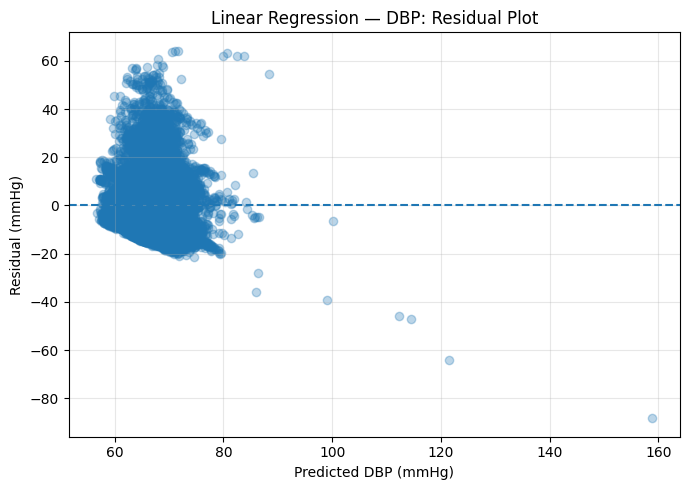

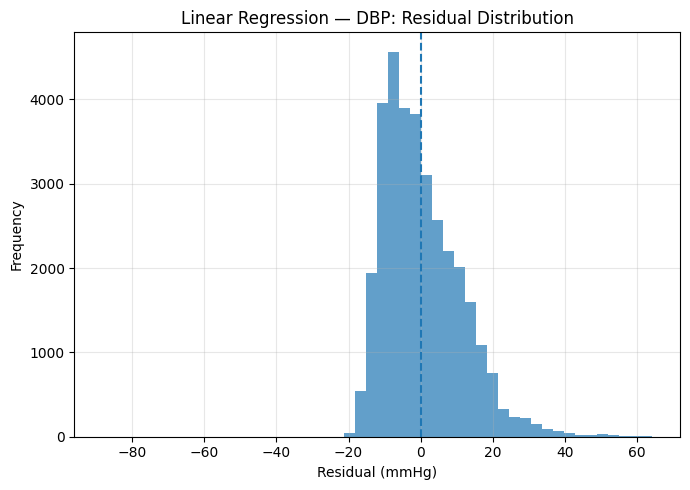

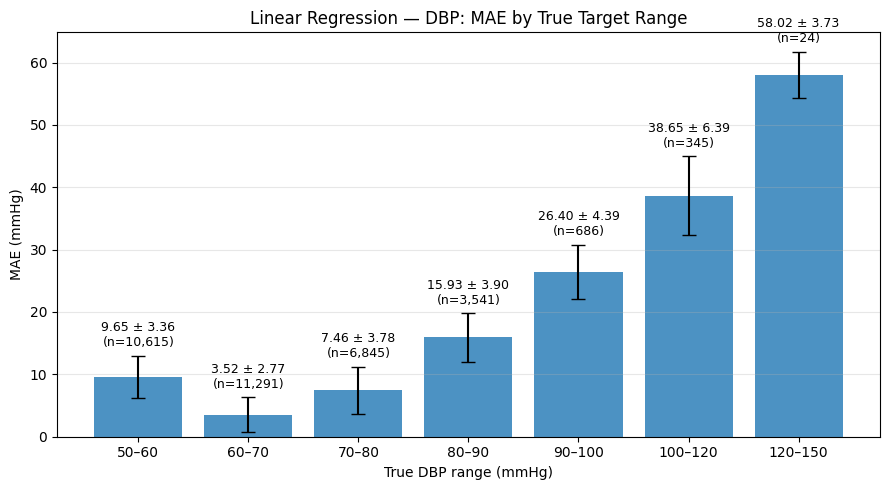

In [11]:
linear_model, y_test_pred = simple_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 17.8346
MSE : 318.0713
R²  : -0.9651
MAE : 11.2956


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


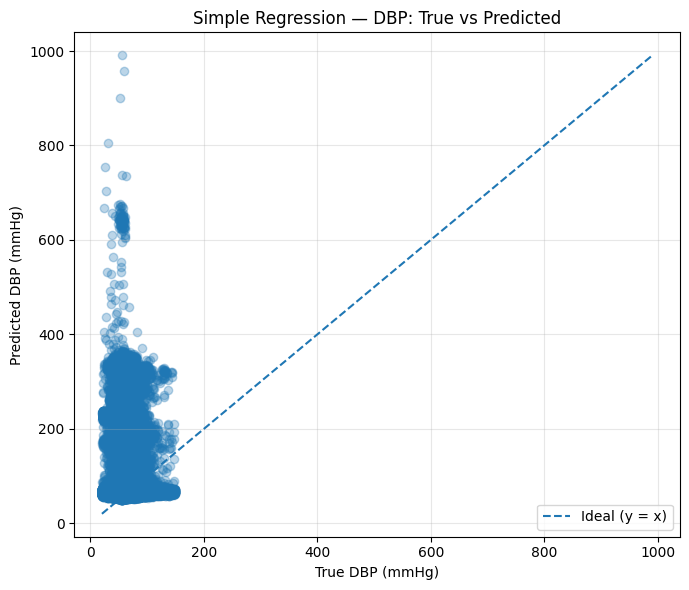

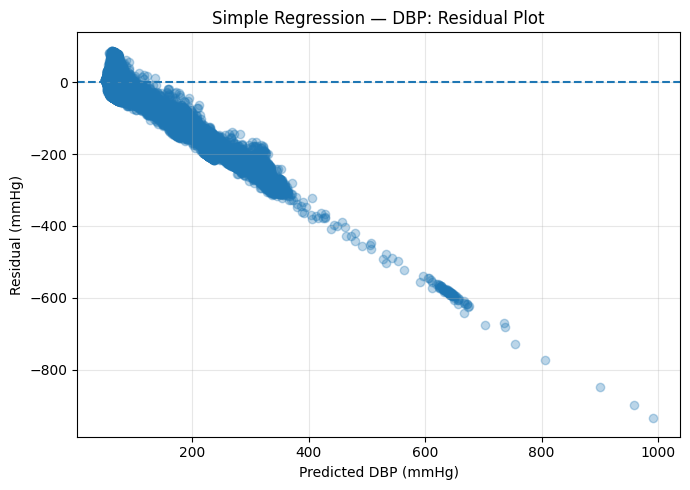

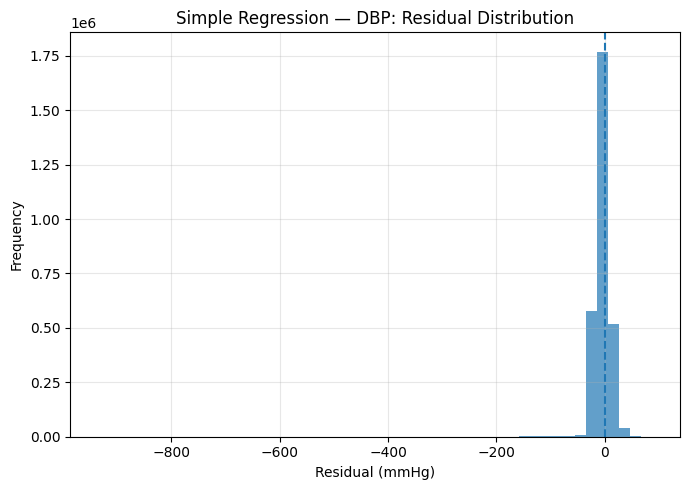

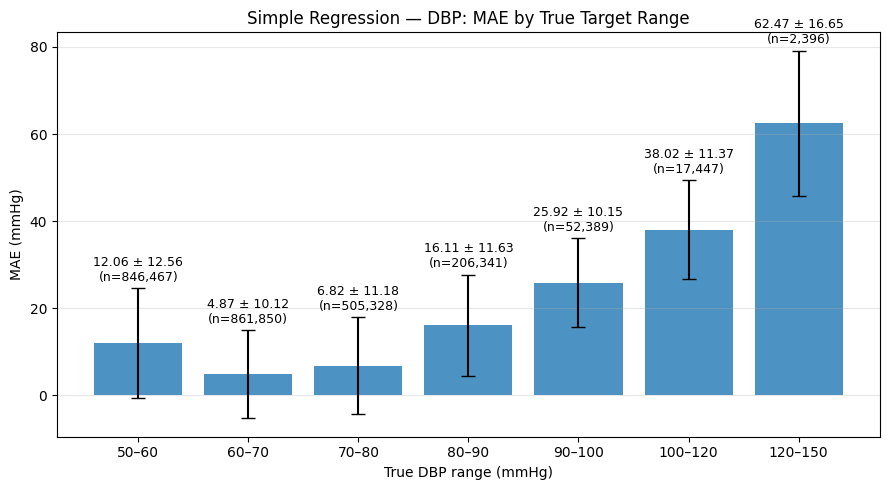

In [12]:
cross_gen(
    X_test_vital,
    y_test_vital,
    linear_model,
    "Simple Regression",
    TARGET
)

## INTERACTION LINEAR REGRESSION ##

Best parameters:
{'linear__fit_intercept': True}

Interaction Linear Regression — DBP
---------------------------------------------
RMSE: 10.1610
MSE : 103.2461
R²  : 0.1735
MAE : 7.9349


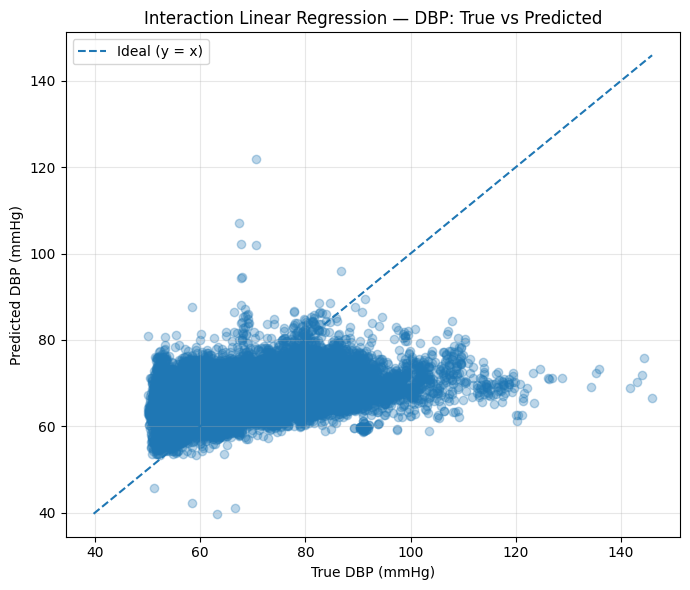

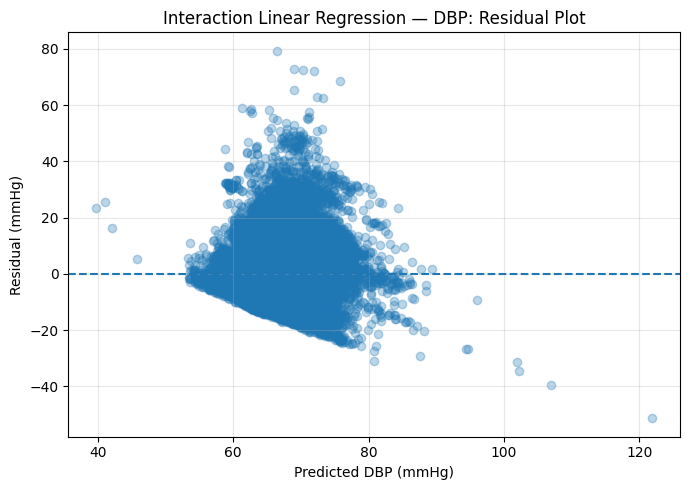

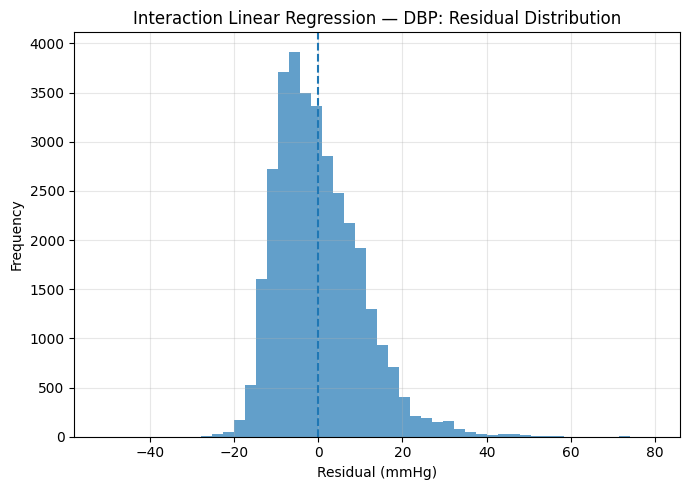

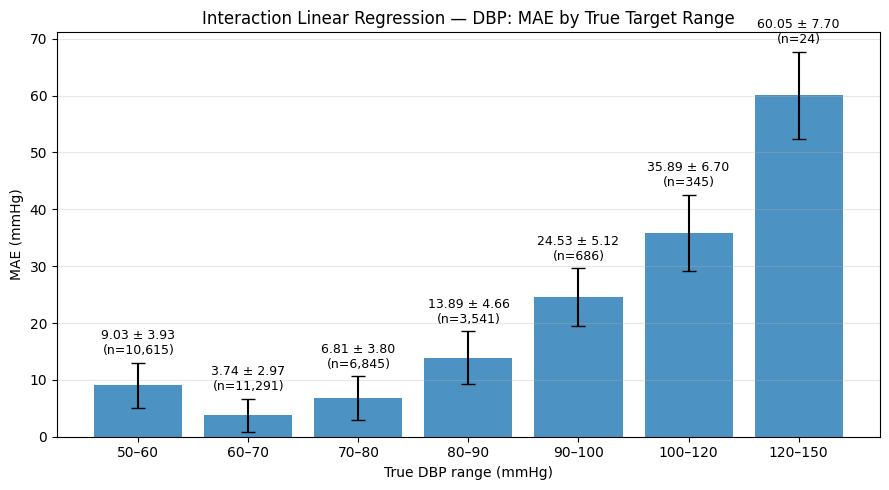

In [13]:
grid_interaction, y_test_pred = interaction_regression(X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 198.9007
MSE : 39561.5073
R²  : -243.4133
MAE : 34.4222


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


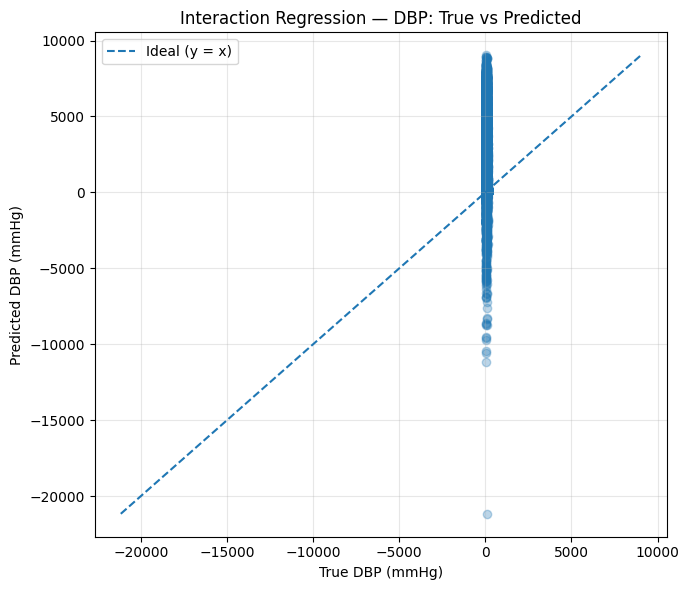

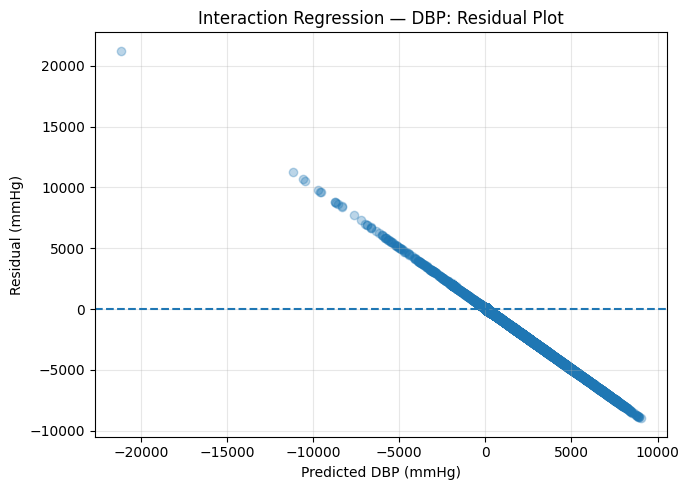

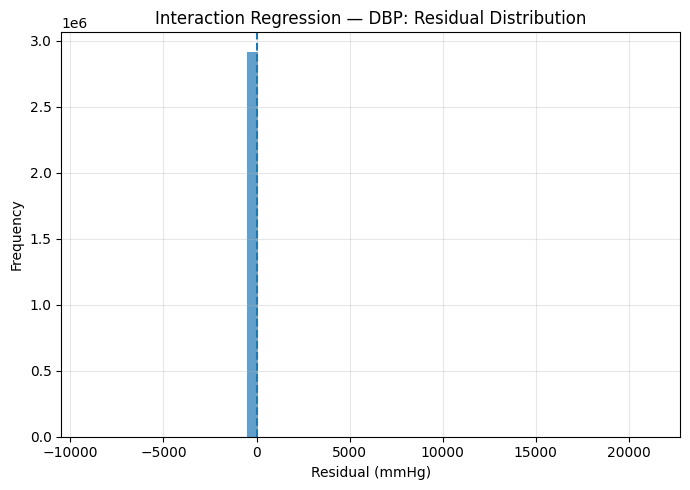

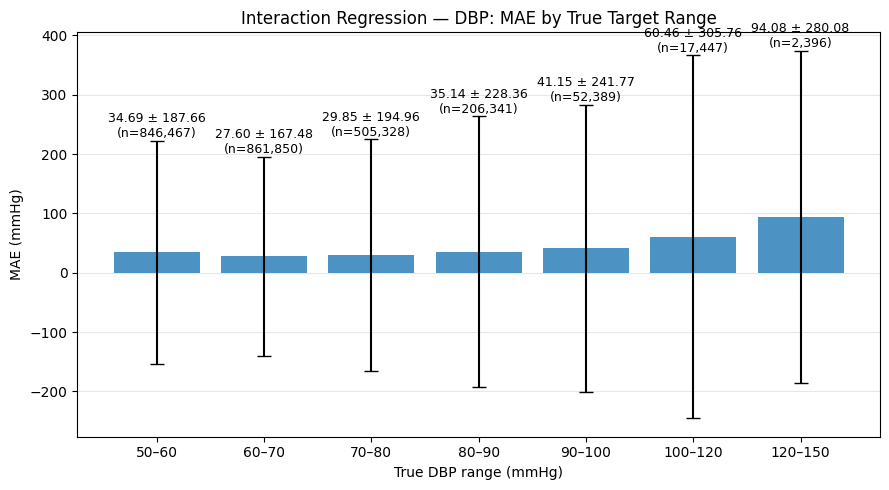

In [14]:
cross_gen(
    X_test_vital,
    y_test_vital,
    grid_interaction,
    "Interaction Regression",
    TARGET
)

## Robust Linear Regression ##

Best parameters:
{'alpha': 1.0, 'epsilon': 2.0}

Robust Linear Regression — DBP
----------------------------------------
RMSE: 10.7898
MSE : 116.4198
R²  : 0.0681
MAE : 8.3755


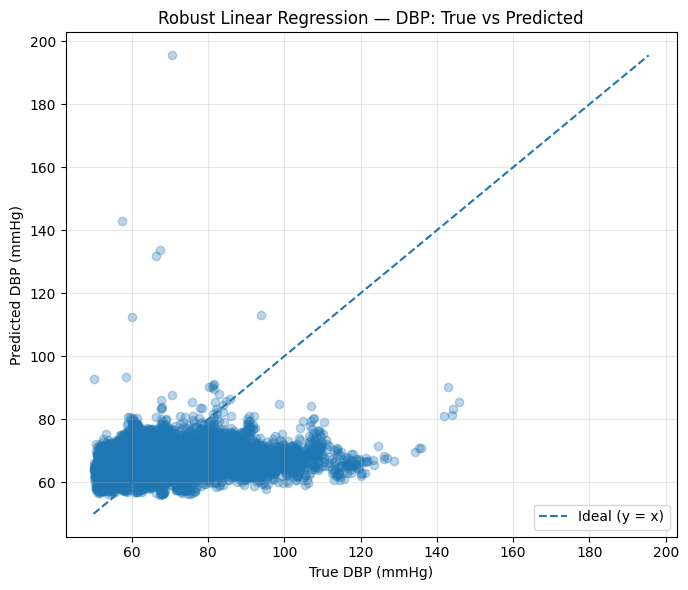

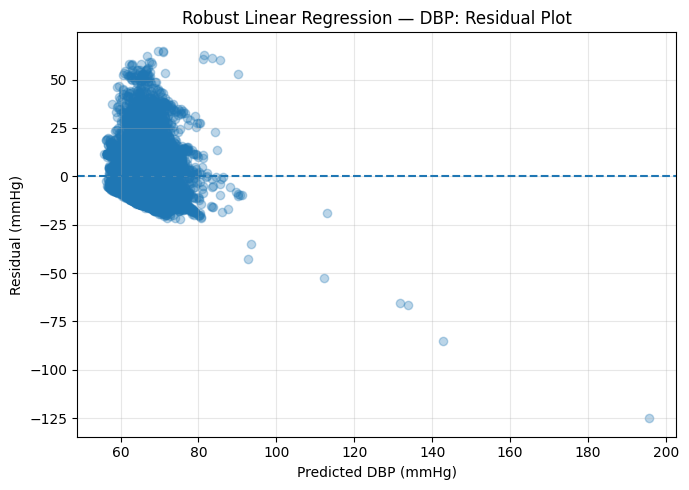

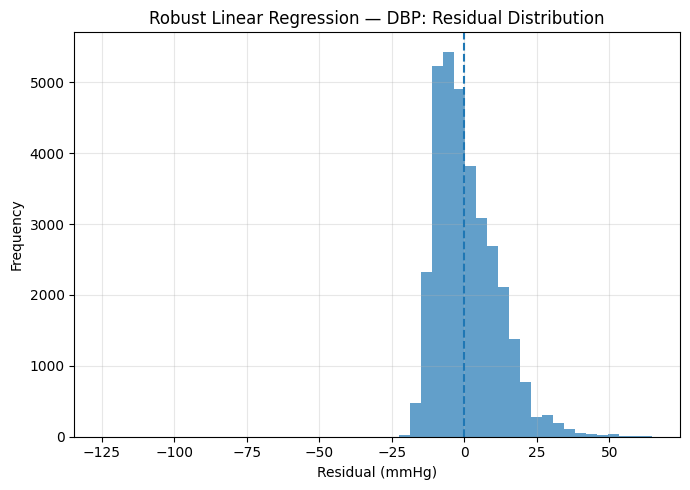

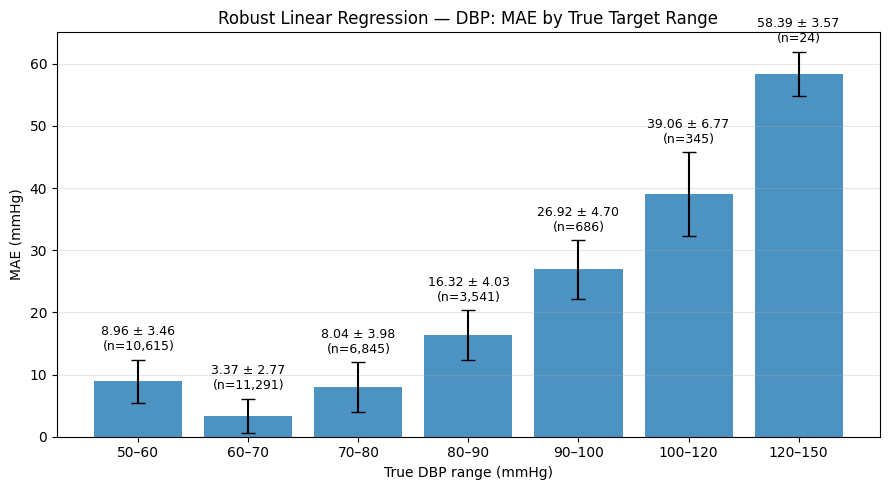

In [15]:
huber_model, y_test_pred = huber_regression(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 15.3410
MSE : 235.3458
R²  : -0.4540
MAE : 11.1910


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


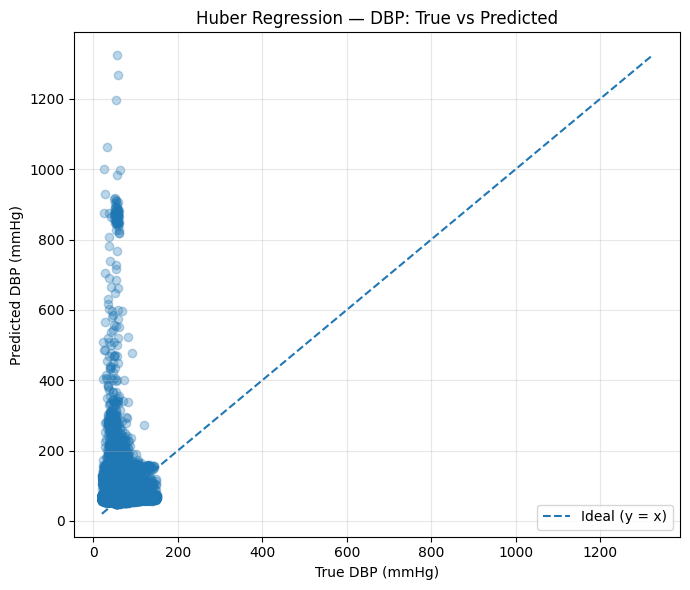

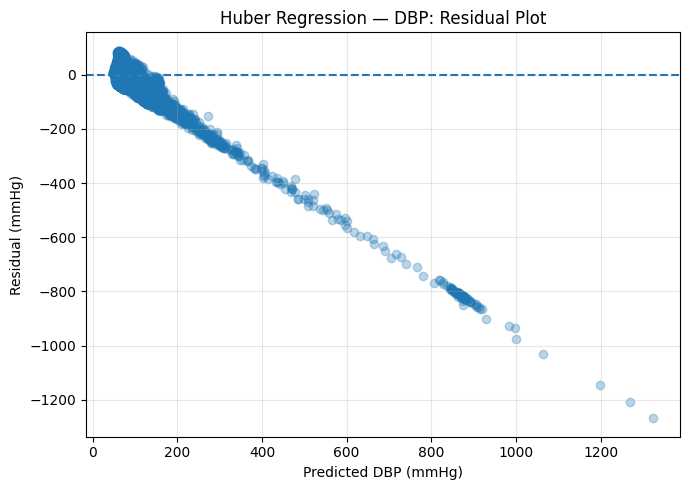

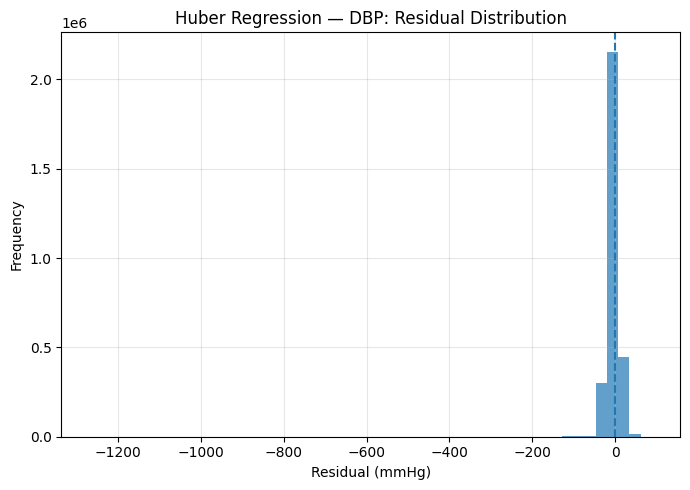

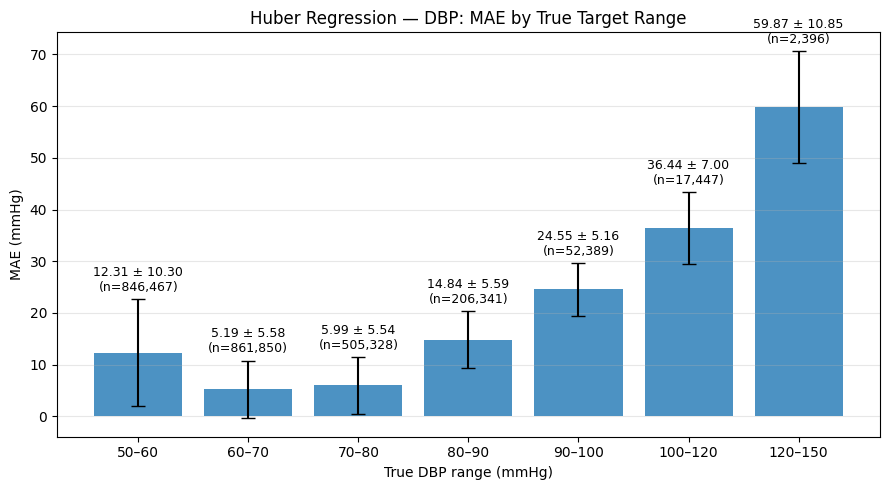

In [16]:
cross_gen(
    X_test_vital,
    y_test_vital,
    huber_model,
    "Huber Regression",
    TARGET
)

## Fine Decision Tree ##

Best parameters:
{'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}

Fine Decision Tree — DBP
--------------------------------
RMSE: 10.0104
MSE : 100.2089
R²  : 0.1978
MAE : 7.4731


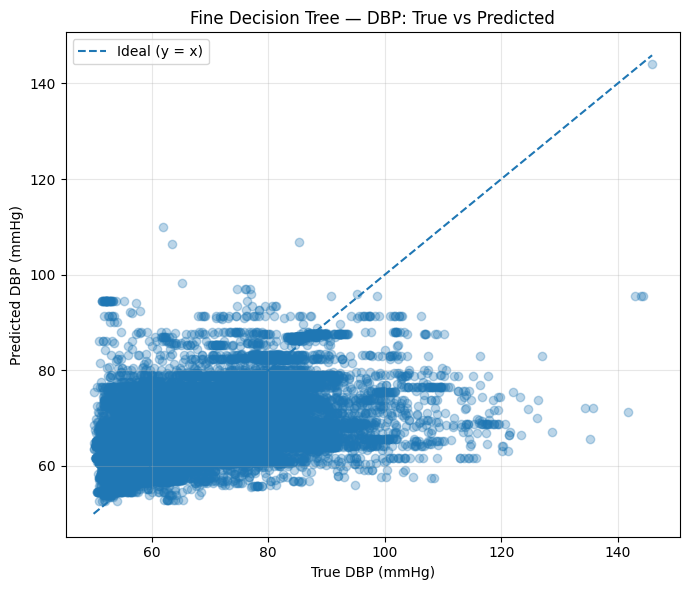

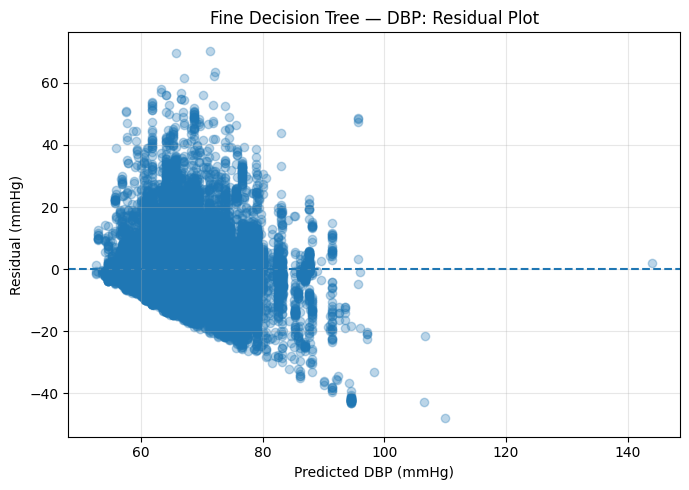

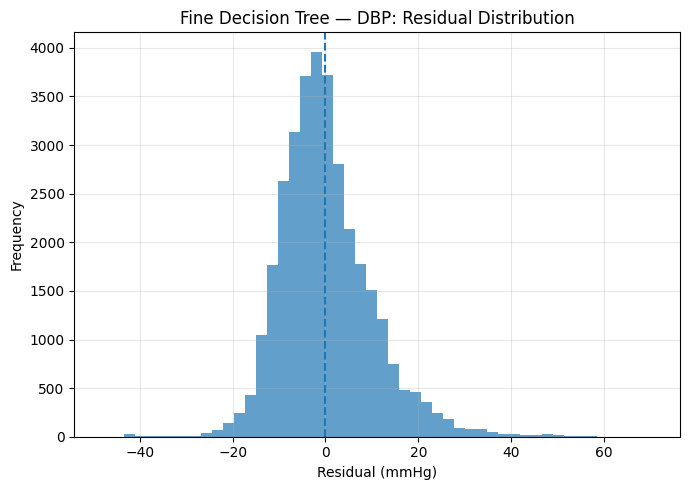

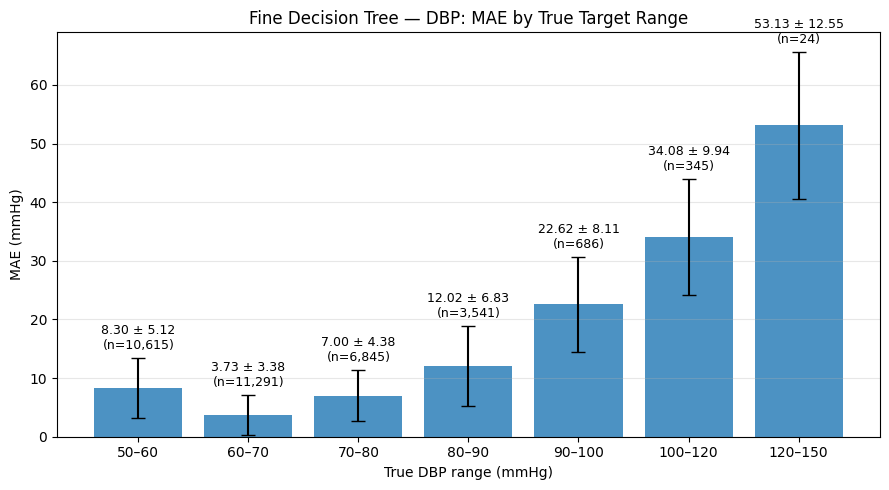

In [17]:
tree_model, y_test_pred = decision_tree(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)


RMSE: 13.7012
MSE : 187.7220
R²  : -0.1598
MAE : 10.9050


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


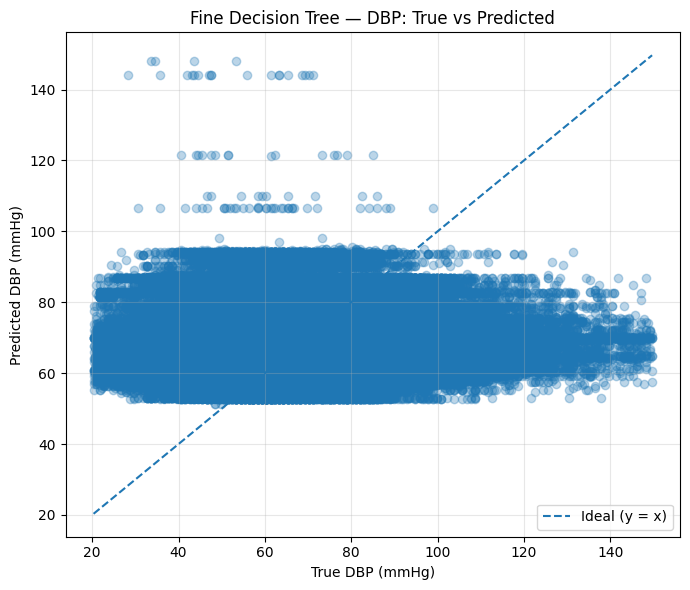

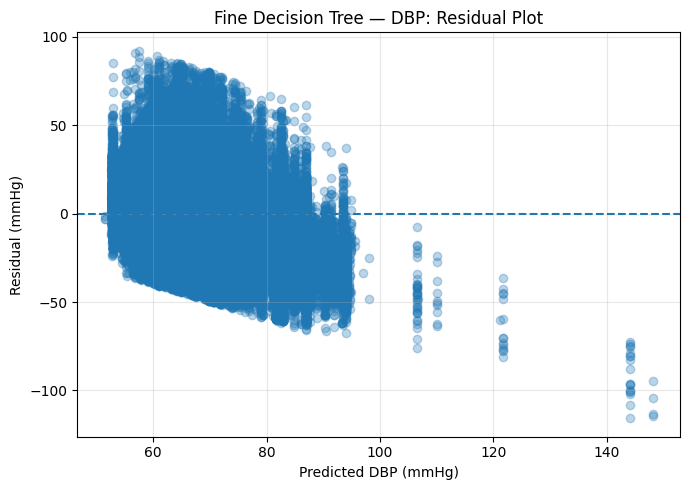

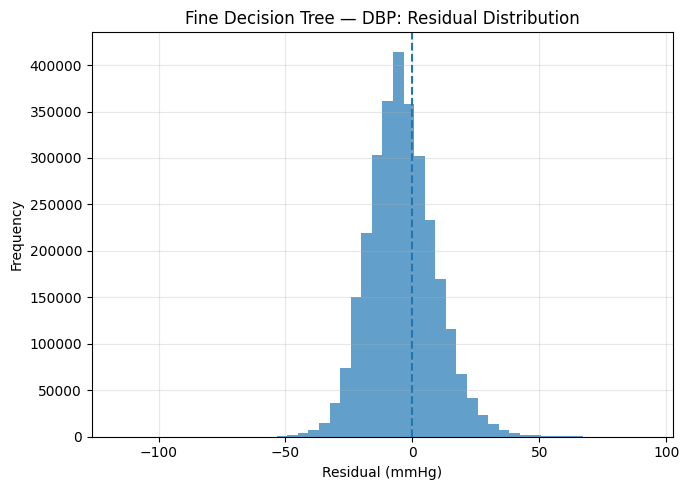

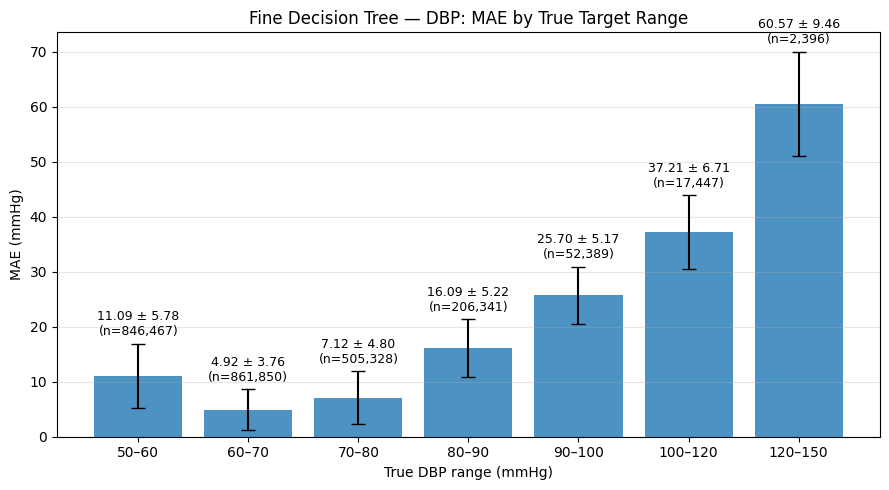

In [18]:
cross_gen(
    X_test_vital,
    y_test_vital,
    tree_model,
    "Fine Decision Tree",
    TARGET
)

## Random Forest ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Random Forest — DBP
----------------------------
RMSE: 8.6855
MSE : 75.4372
R²  : 0.3961
MAE : 6.3427


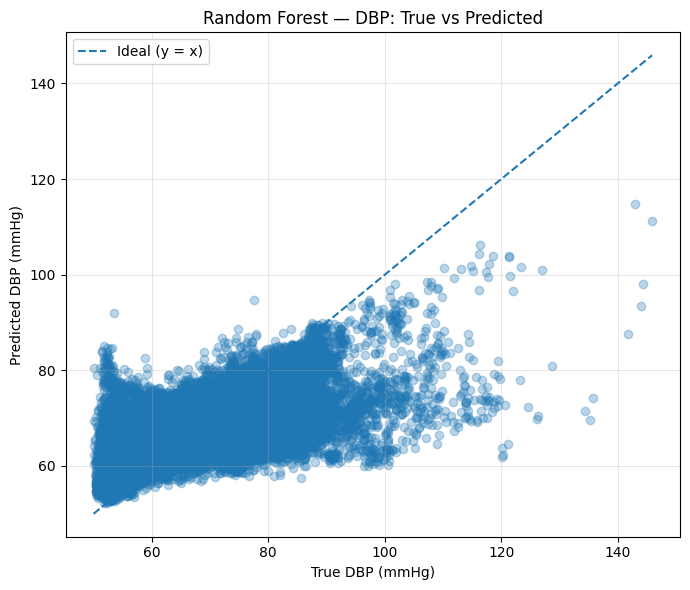

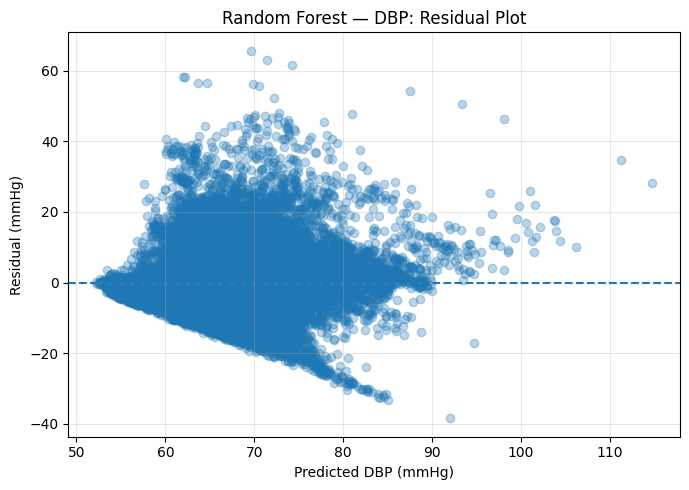

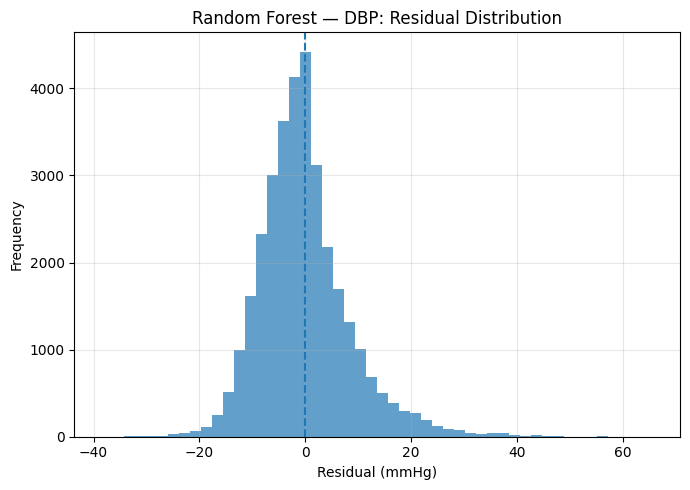

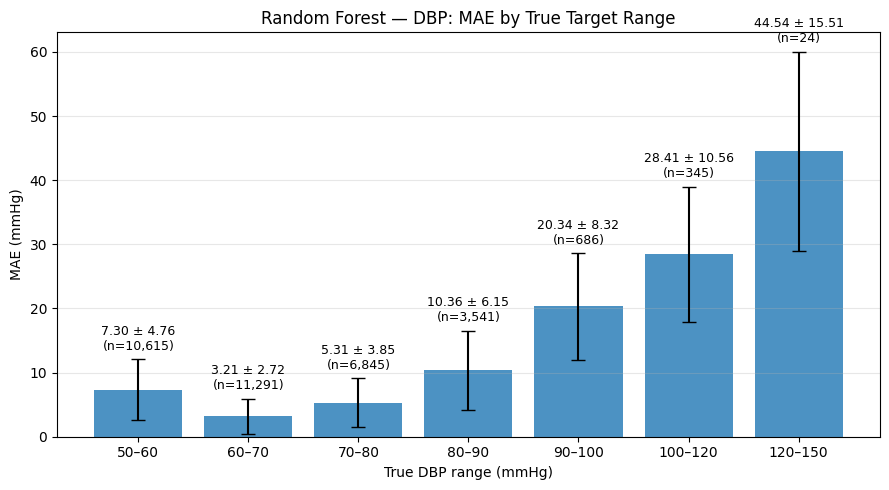

In [19]:
rf_model, y_test_pred = random_forest(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.9223
MSE : 193.8314
R²  : -0.1975
MAE : 11.2715


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


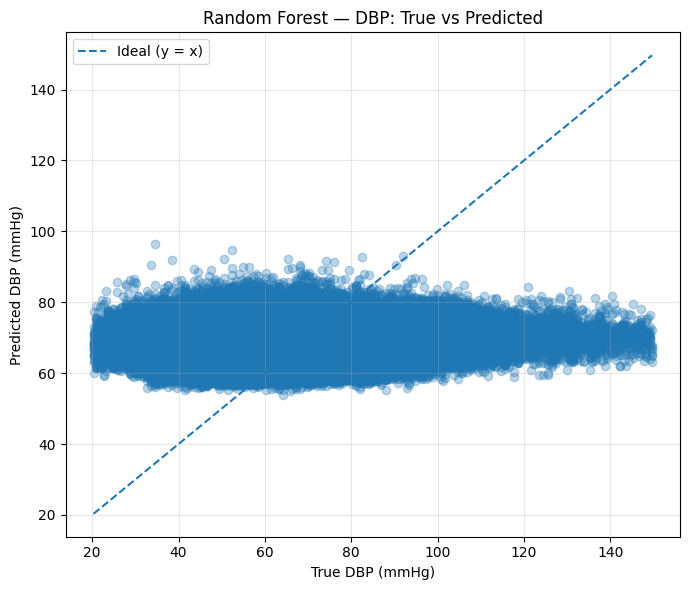

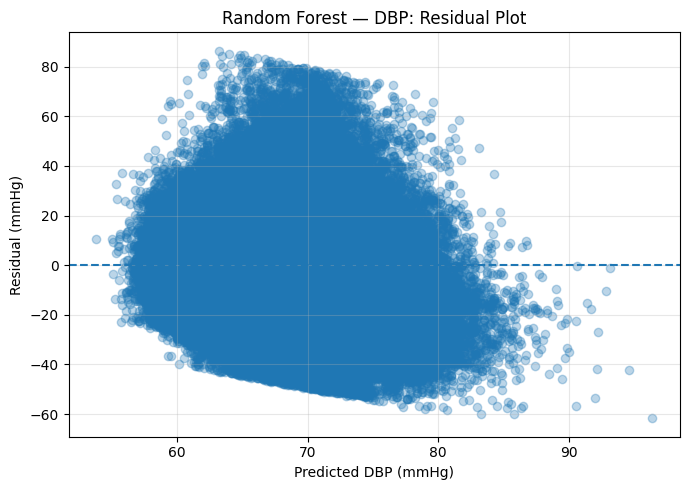

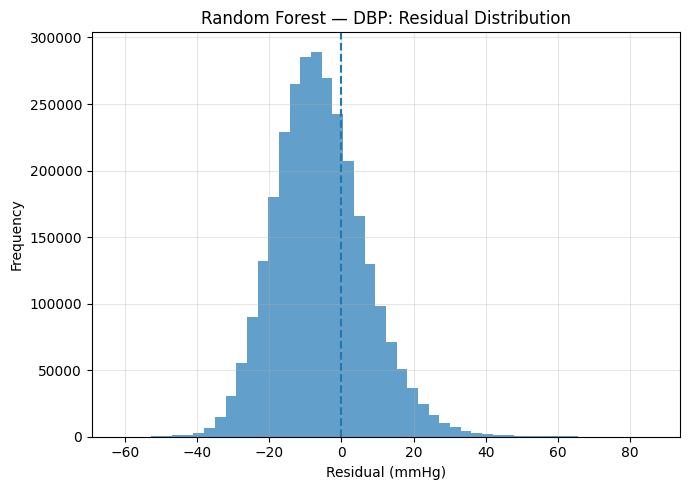

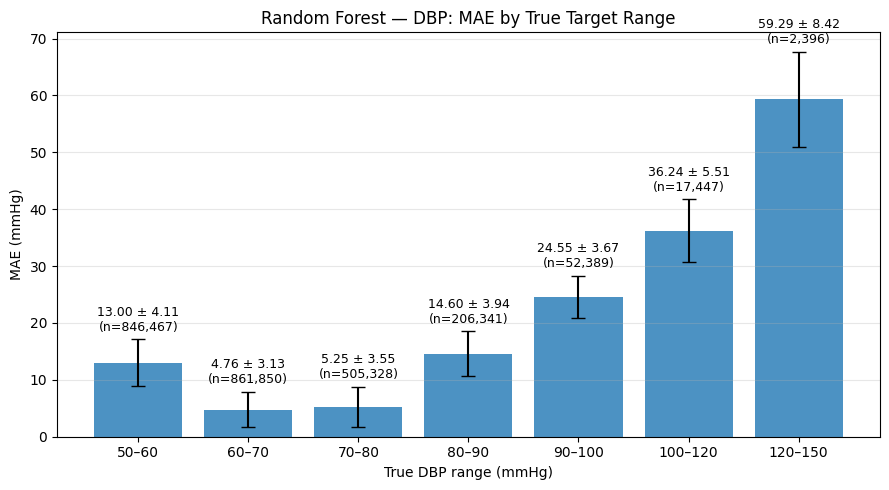

In [20]:
cross_gen(
    X_test_vital,
    y_test_vital,
    rf_model,
    "Random Forest",
    TARGET
)

## Extra TREES ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'max_depth': None, 'max_features': 1.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Extra Trees Regressor — DBP
--------------------------------------
RMSE: 8.6062
MSE : 74.0666
R²  : 0.4071
MAE : 6.2136


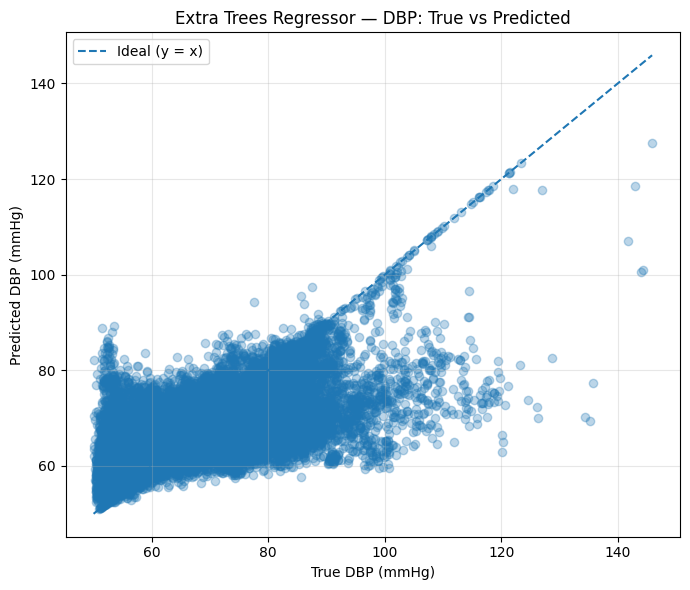

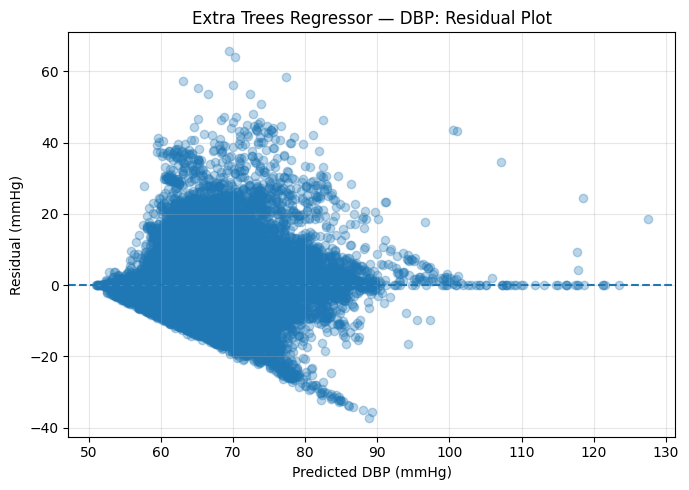

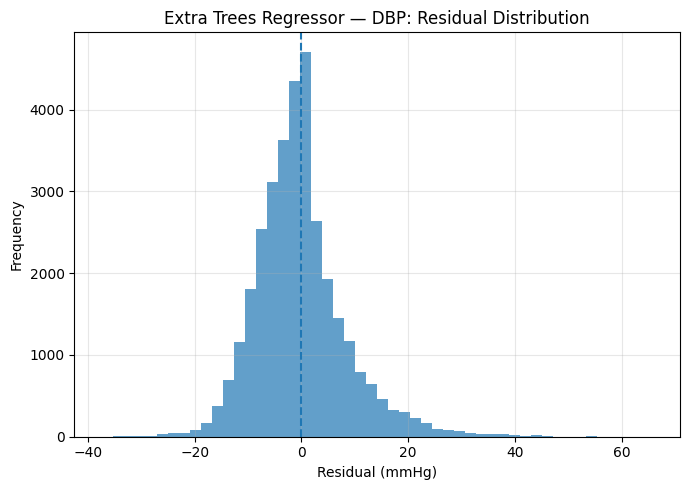

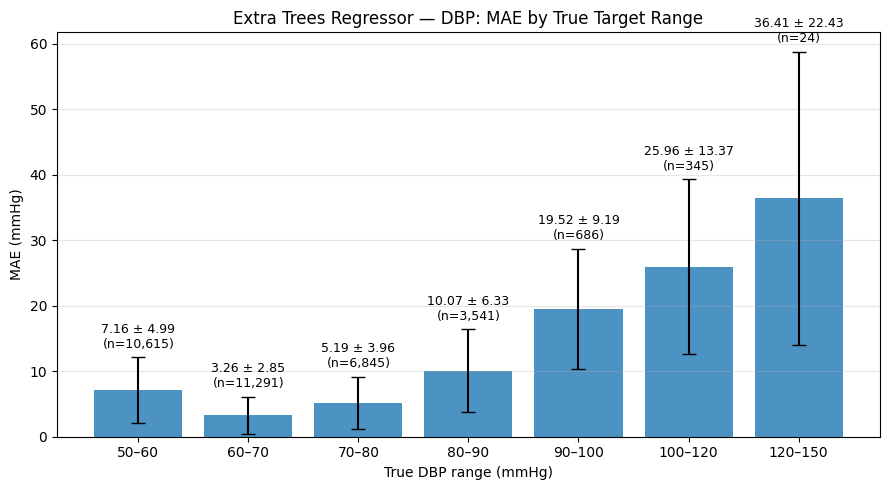

In [21]:
extra_trees_model, y_test_pred = extra_trees(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 14.9481
MSE : 223.4467
R²  : -0.3805
MAE : 12.2084


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


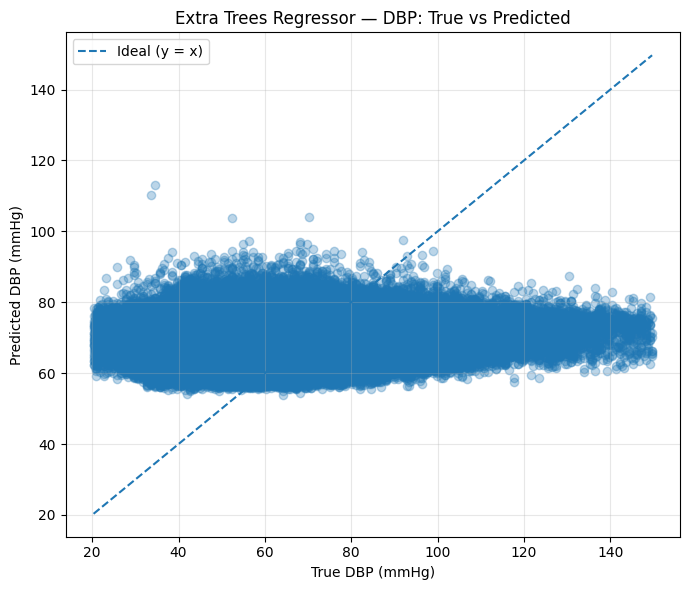

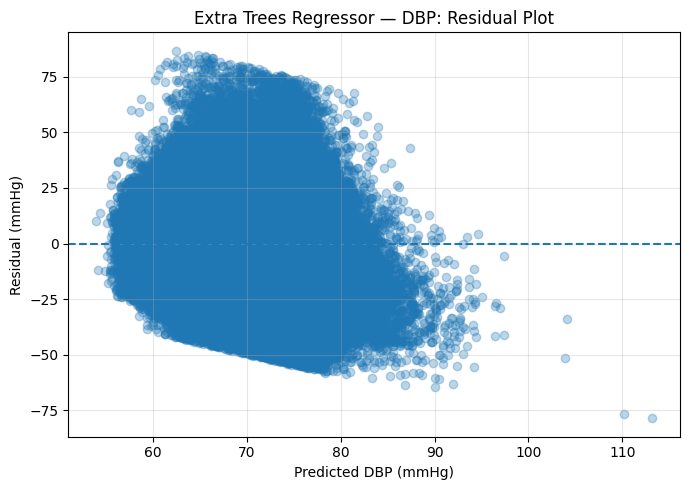

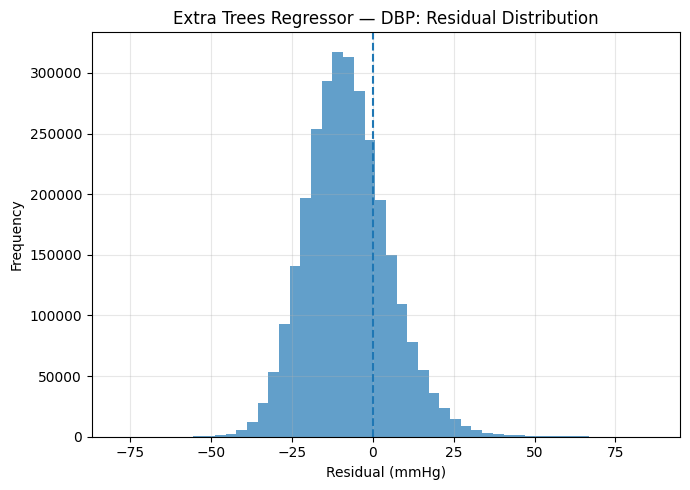

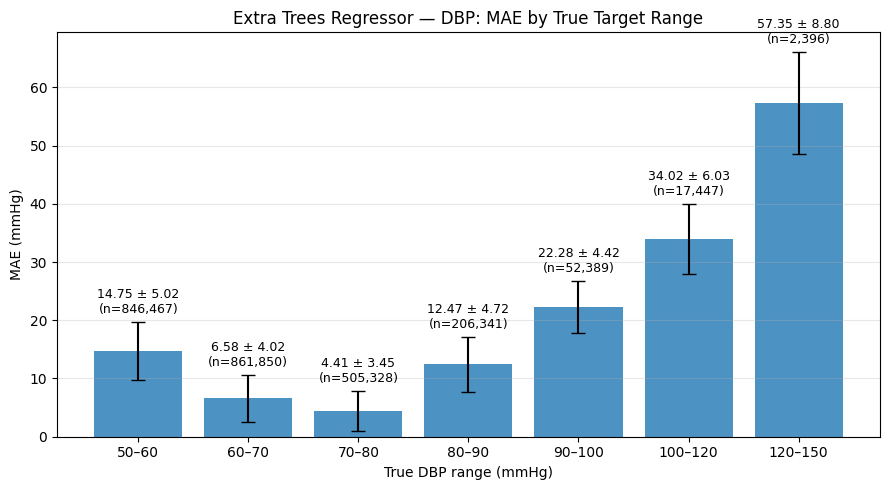

In [22]:
cross_gen(
    X_test_vital,
    y_test_vital,
    extra_trees_model,
    "Extra Trees Regressor",
    TARGET
)

## XGBOOST ##

/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}

XGBoost — DBP
---------------------
RMSE: 9.2017
MSE : 84.6718
R²  : 0.3222
MAE : 6.8294


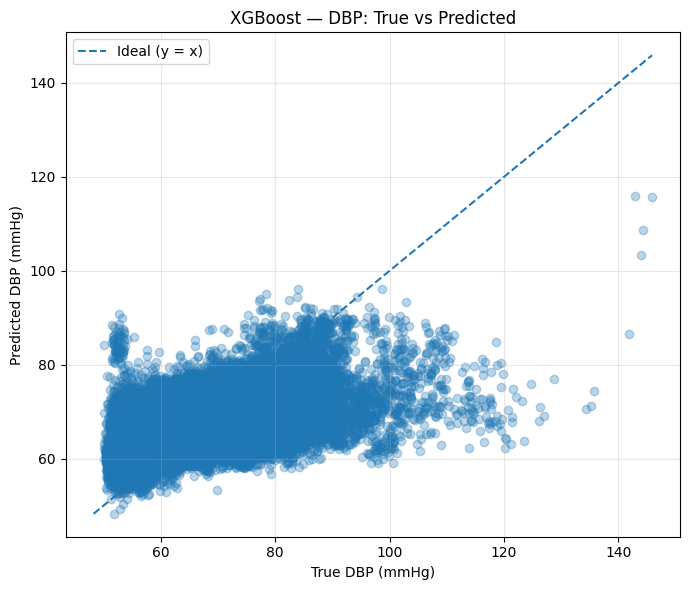

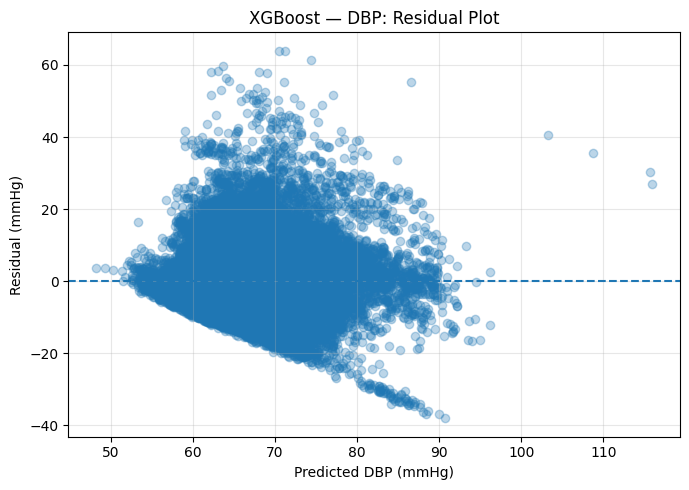

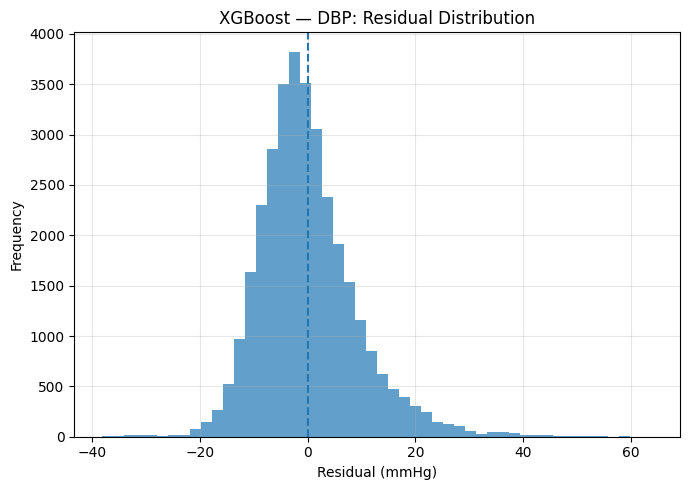

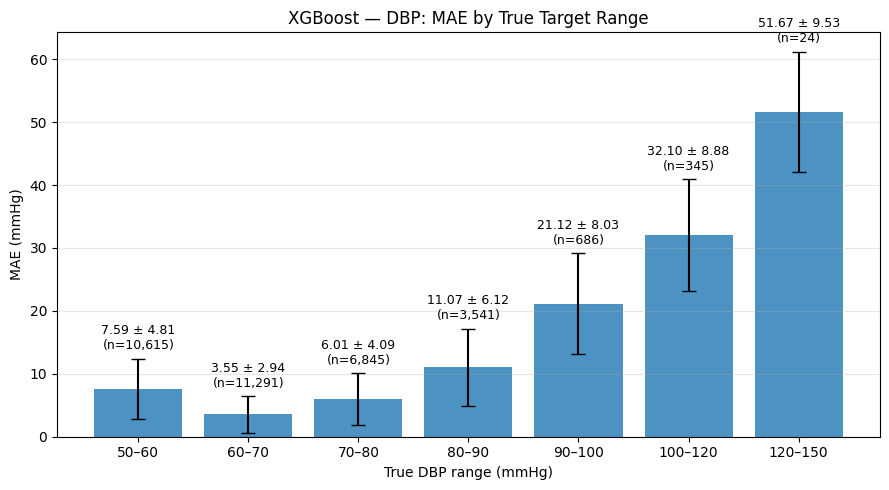

In [23]:
xgbmodel, y_test_pred = xgboost_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 15.7817
MSE : 249.0606
R²  : -0.5387
MAE : 12.5599


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


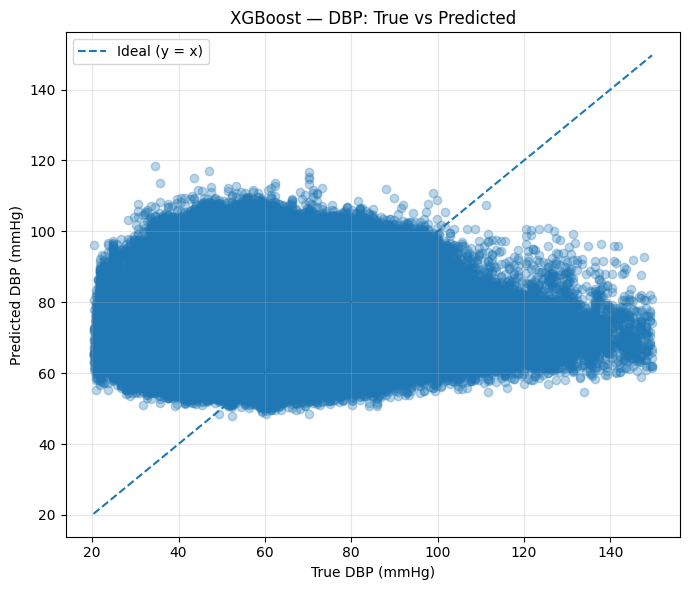

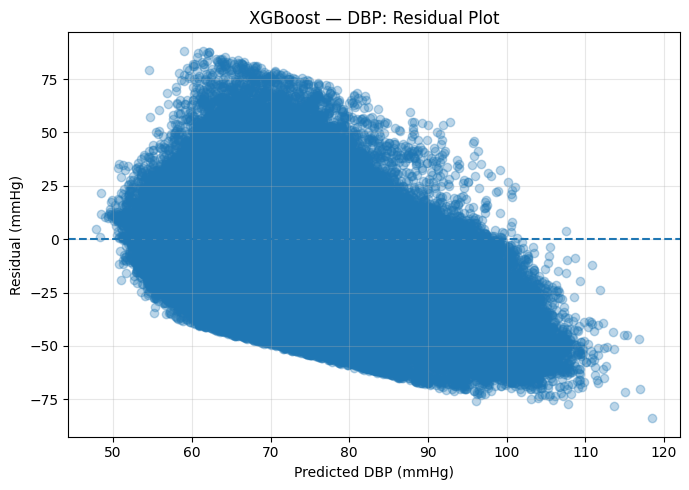

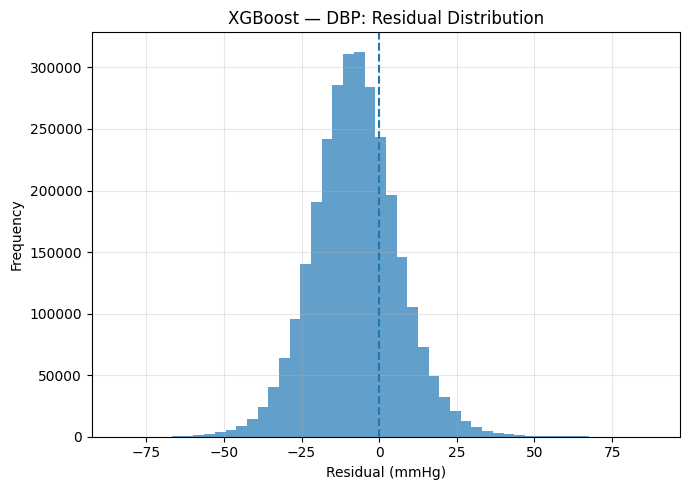

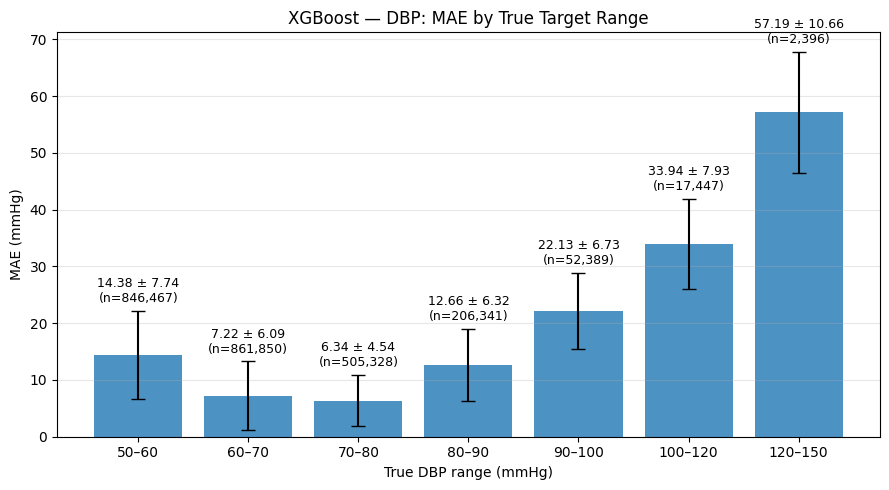

In [24]:
cross_gen(
    X_test_vital,
    y_test_vital,
    xgbmodel,
    "XGBoost",
    TARGET
)

## Light GBM ##

Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   0.5s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   0.6s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=15; total time=   0.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.8s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=100, num_leaves=31; total time=   0.7s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total time=   1.0s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=31; total time=   1.3s
[CV] END learning_rate=0.05, max_depth=-1, n_estimators=200, num_leaves=15; total ti

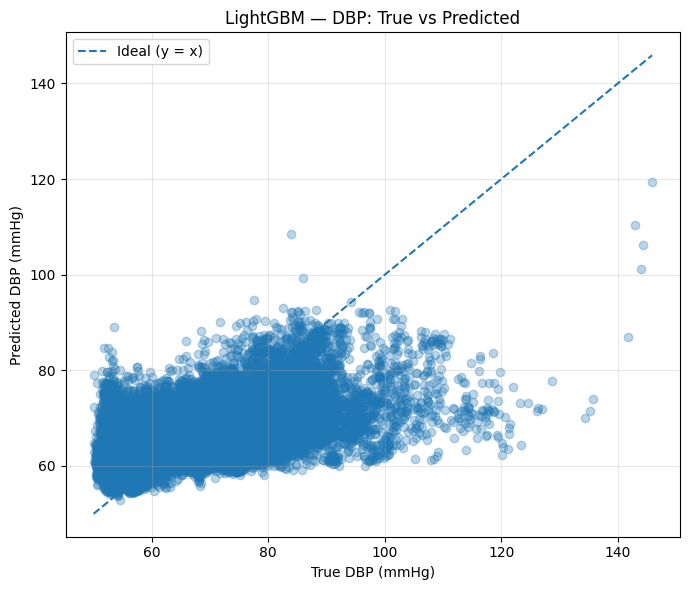

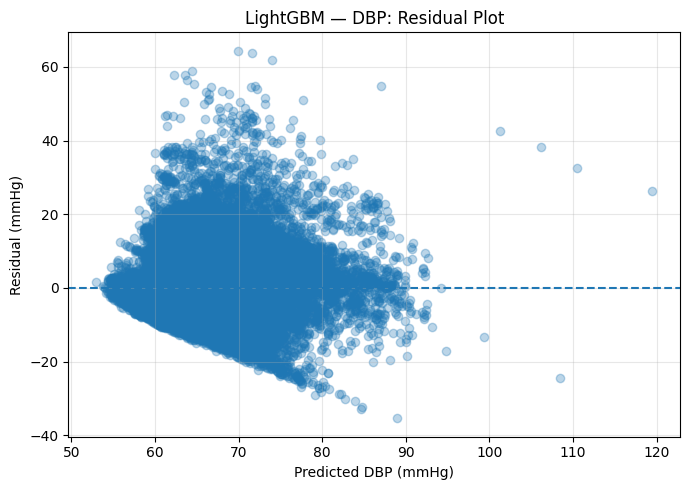

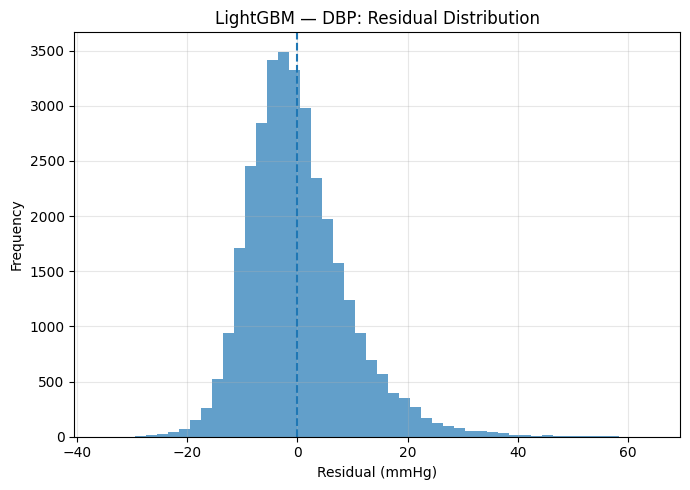

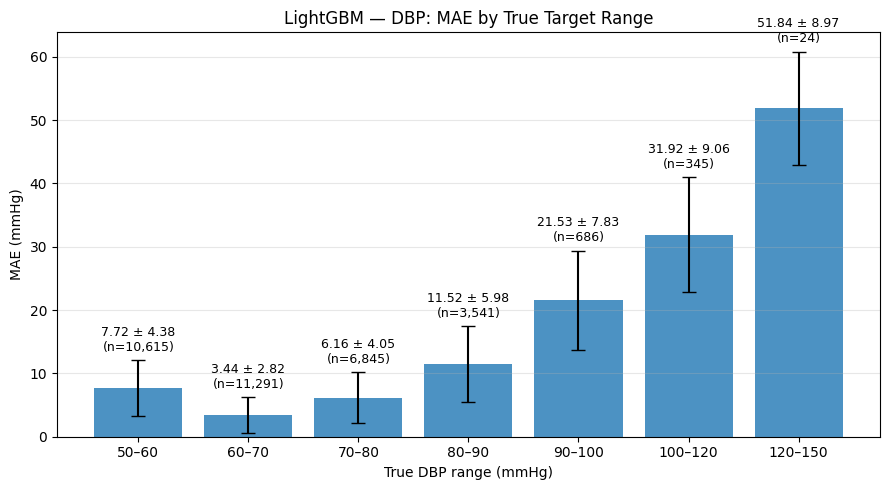

In [25]:
lgbmmodel, y_test_pred = lightgbm_model(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.3019
MSE : 176.9403
R²  : -0.0931
MAE : 10.5723


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


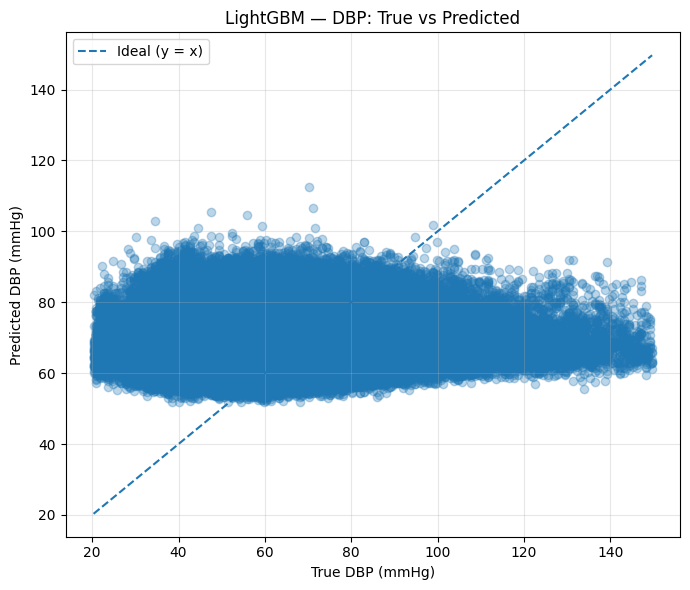

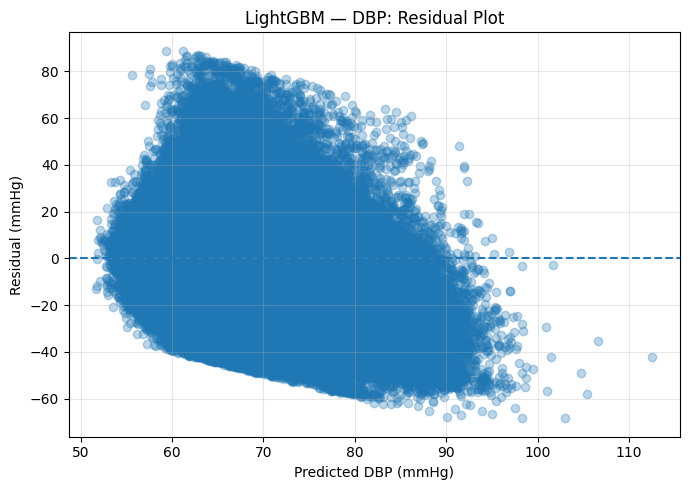

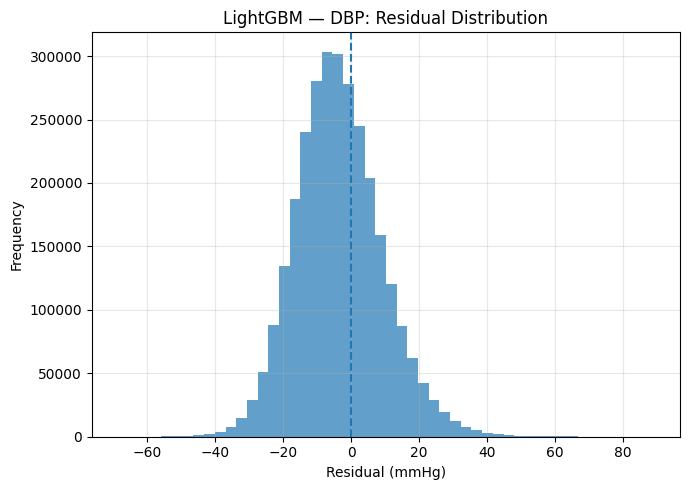

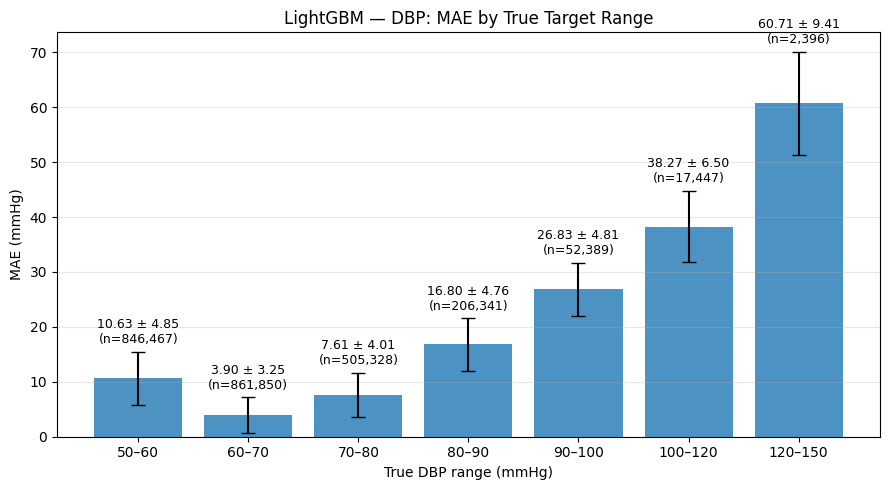

In [26]:
cross_gen(
    X_test_vital,
    y_test_vital,
    lgbmmodel,
    "LightGBM",
    TARGET
)

##  Matern 5/2 gpr ##

Best parameters:
{'kernel': 1**2 * Matern(length_scale=2, nu=2.5) + WhiteKernel(noise_level=1)}

Matern 5/2 GPR — DBP
--------------------------------
RMSE: 9.8808
MSE : 97.6293
R²  : 0.2185
MAE : 7.5231


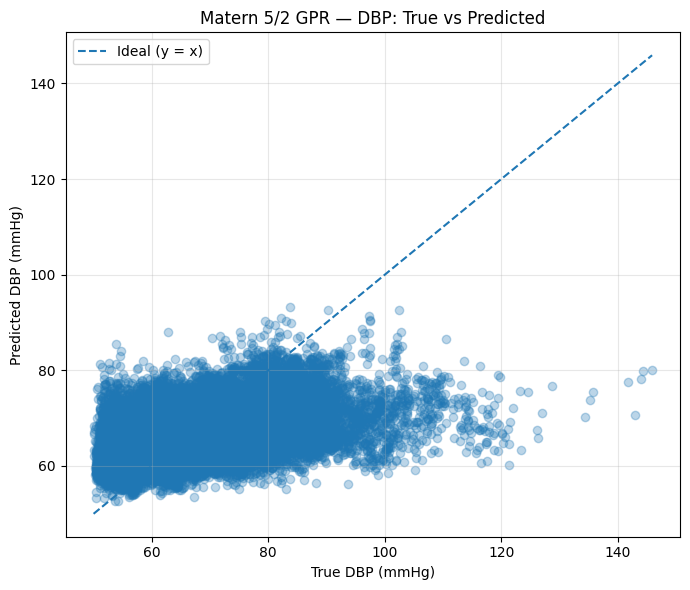

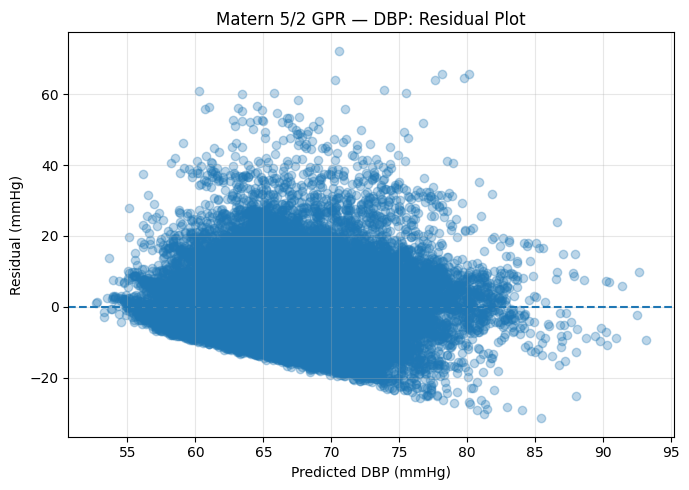

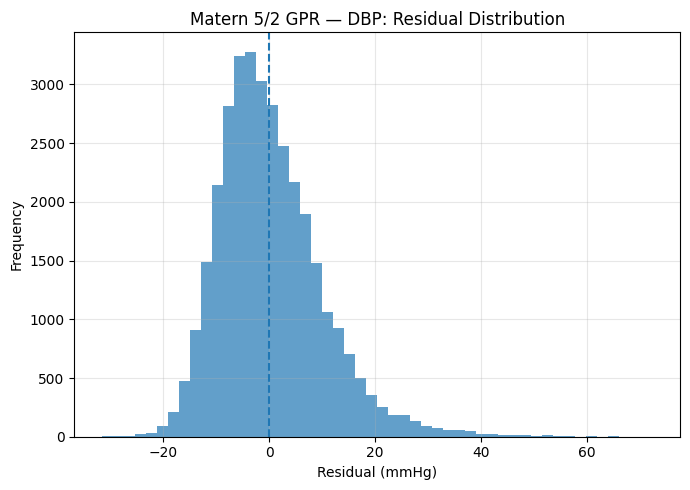

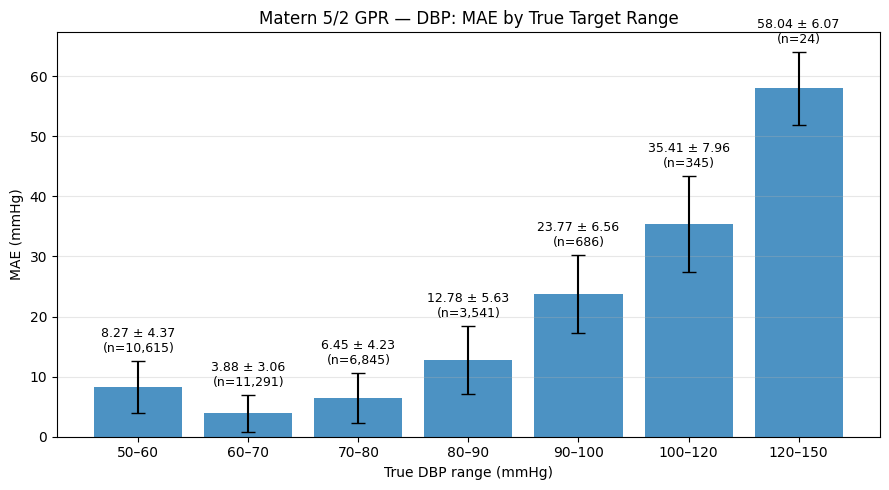

In [27]:
gpr_model, y_test_pred = gpr_matern(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET)

RMSE: 13.3174
MSE : 177.3519
R²  : -0.0957
MAE : 10.6996


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


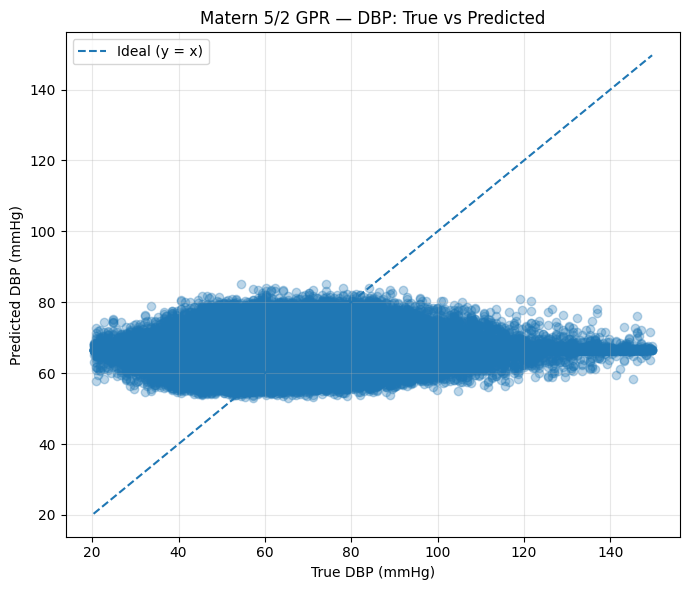

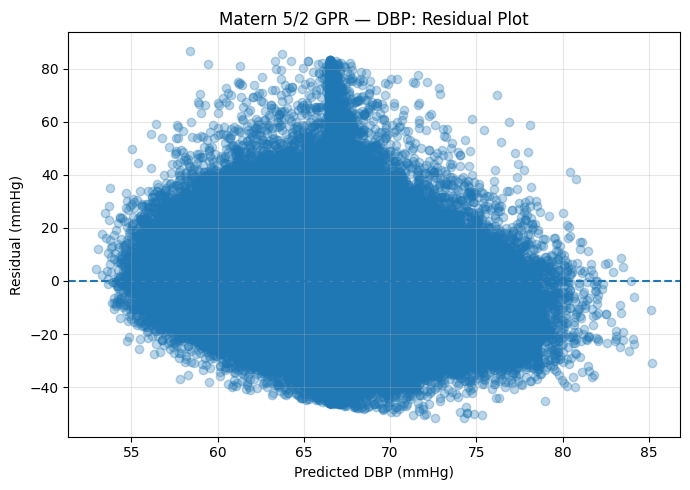

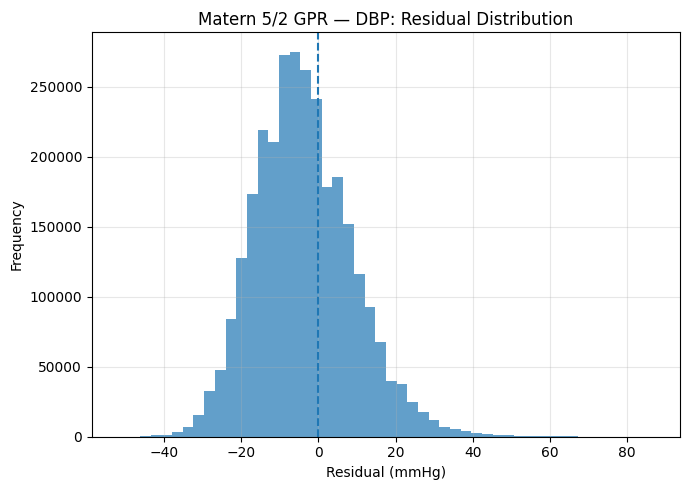

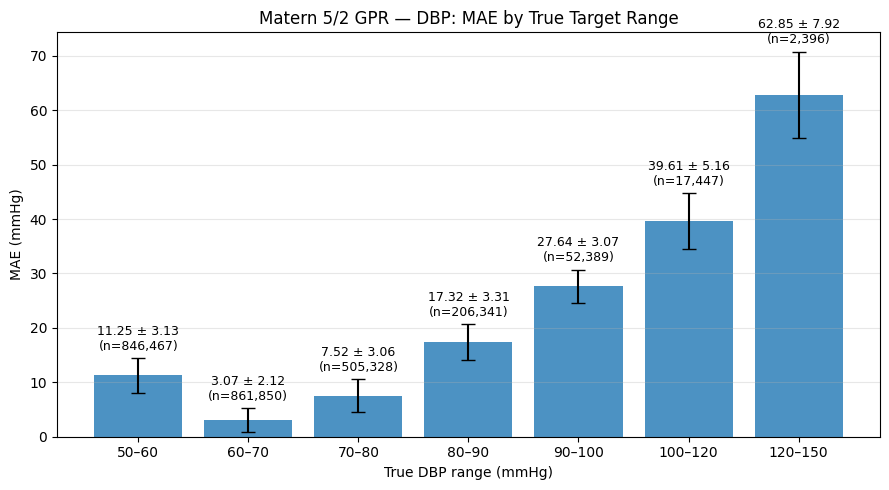

In [28]:
y_pred_vitaldb = predict_gpr_in_batches(
    model=gpr_model,
    X=X_test_vital,
    y_test=y_test_vital,
    target_name=TARGET,
    model_name="Matern 5/2 GPR",
    batch_size=10000
)

## Rational Quadratic GPR ##

GPR training samples: 5,000

Starting Rational Quadratic GPR GridSearch...
Fitting 3 folds for each of 3 candidates, totalling 9 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-08. Decreasing the bound and calling fit again may find a bette


Best parameters:
{'kernel': 1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1)}

Best CV RMSE: 9.616369858367657

Best GPR model:
GaussianProcessRegressor(kernel=1**2 * RationalQuadratic(alpha=1, length_scale=1) + WhiteKernel(noise_level=1),
                         normalize_y=True, random_state=42)

Starting batched prediction on 33,347 samples...
RMSE: 9.8480
MSE : 96.9826
R²  : 0.2237
MAE : 7.4998


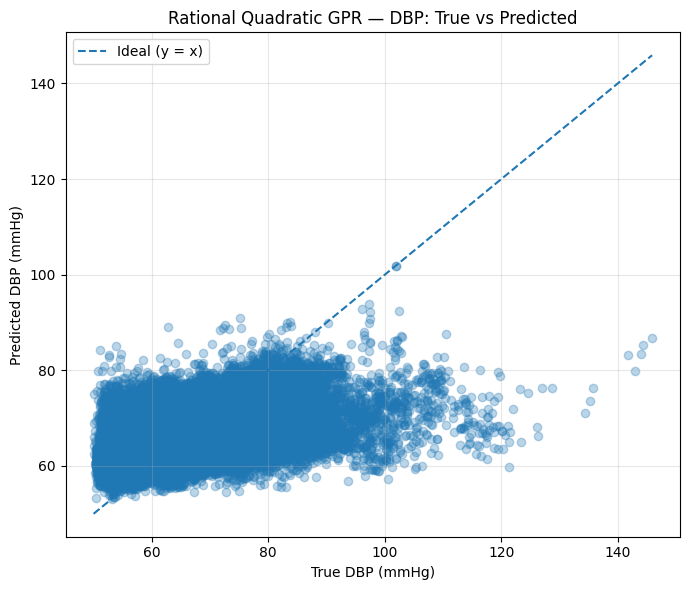

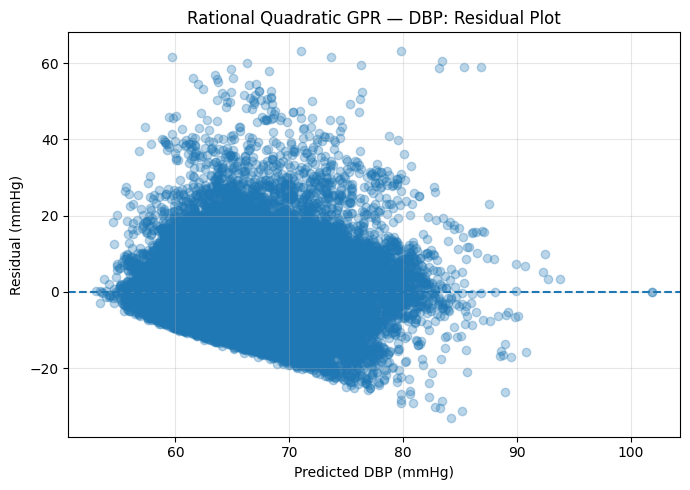

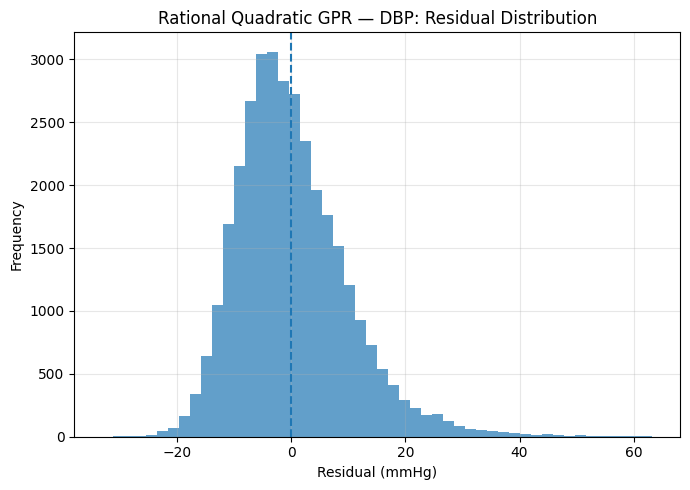

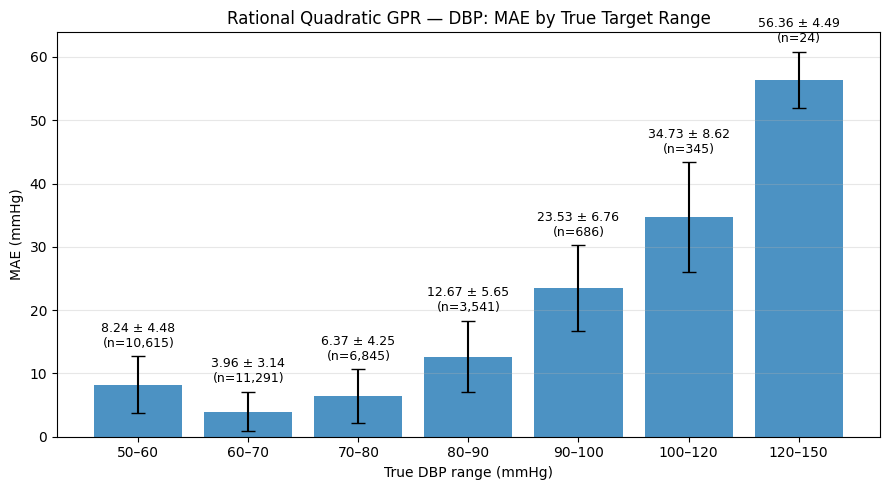

In [29]:
rq_model, y_test_pred = gpr_rational_quadratic(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

RMSE: 13.4639
MSE : 181.2778
R²  : -0.1199
MAE : 10.8421


/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


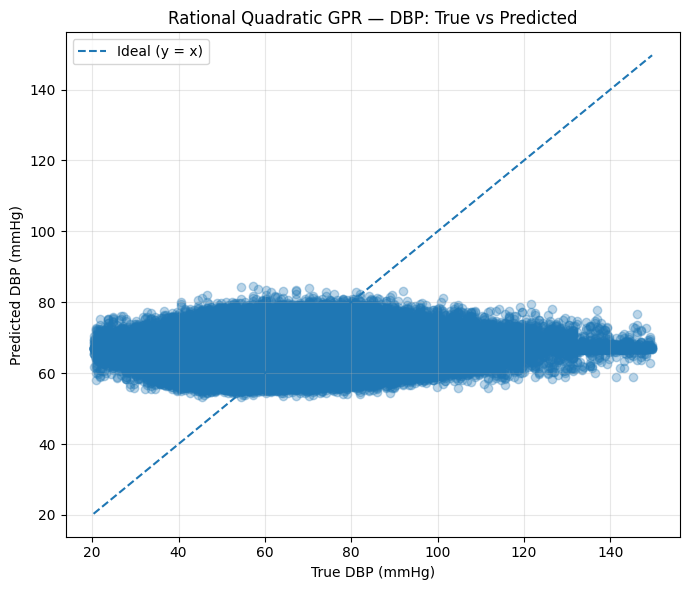

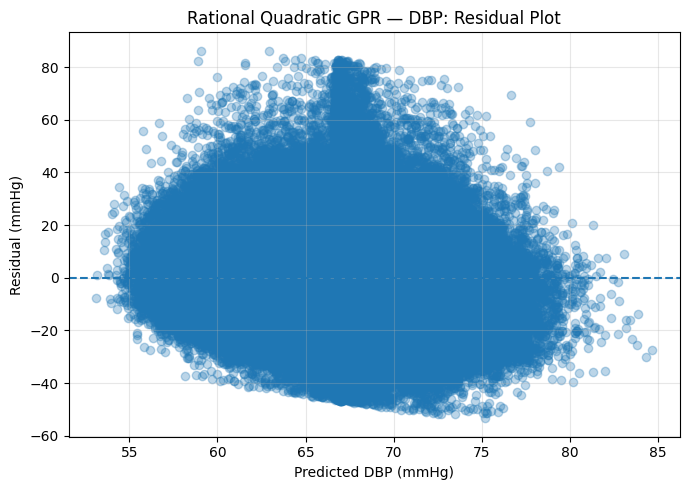

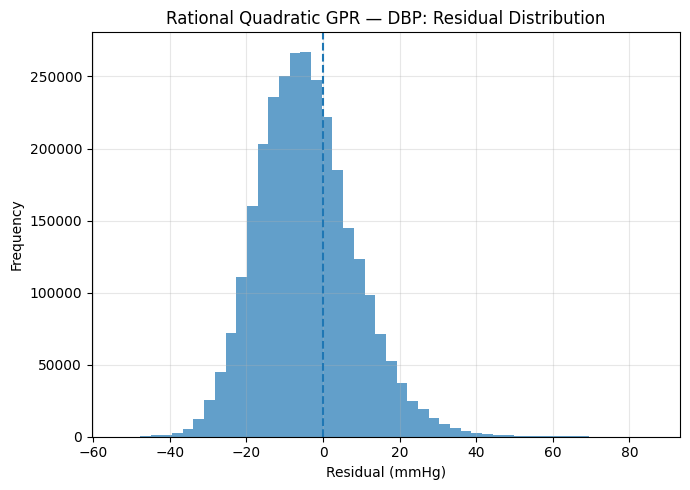

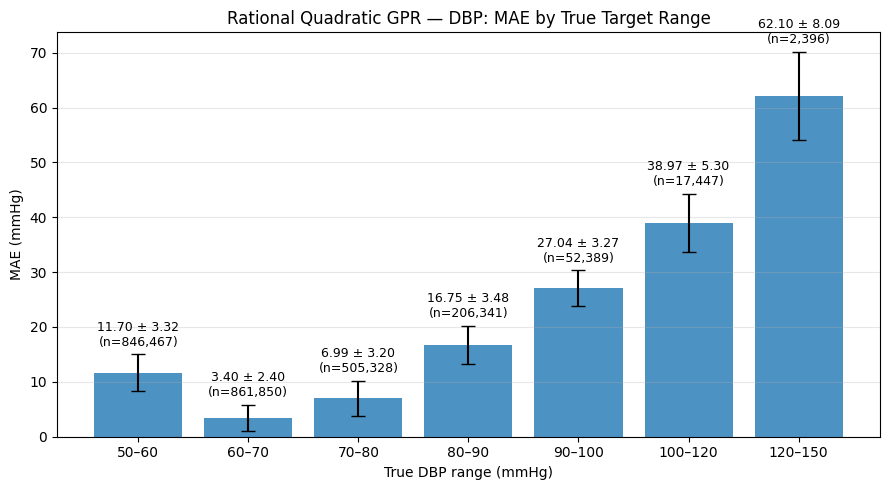

In [30]:
y_pred_vitaldb = predict_gpr_in_batches(
    rq_model,
    X_test_vital,
    y_test_vital,
    target_name=TARGET,
    model_name="Rational Quadratic GPR",
    batch_size=10000
)

## ANN ##

ANN training samples: 5,000

Starting ANN / MLP GridSearch...
Fitting 3 folds for each of 36 candidates, totalling 108 fits


/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum i


Best parameters:
{'activation': 'relu', 'alpha': 0.01, 'batch_size': 256, 'hidden_layer_sizes': (128, 64), 'learning_rate_init': 0.01}

Best CV RMSE: 10.46564839888611

Best ANN / MLP model:
MLPRegressor(alpha=0.01, batch_size=256, early_stopping=True,
             hidden_layer_sizes=(128, 64), learning_rate_init=0.01,
             max_iter=300, n_iter_no_change=20, random_state=42)

Starting batched prediction on 33,347 samples...
Processed 10,000 / 33,347
Processed 20,000 / 33,347
Processed 30,000 / 33,347
Processed 33,347 / 33,347

ANN / MLP Regressor — DBP
------------------------------------
RMSE: 10.2986
MSE : 106.0616
R²  : 0.1510
MAE : 7.9872


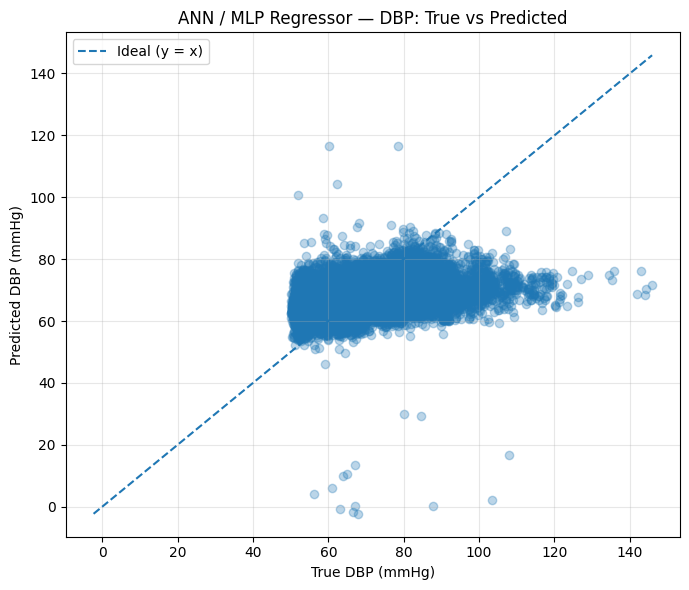

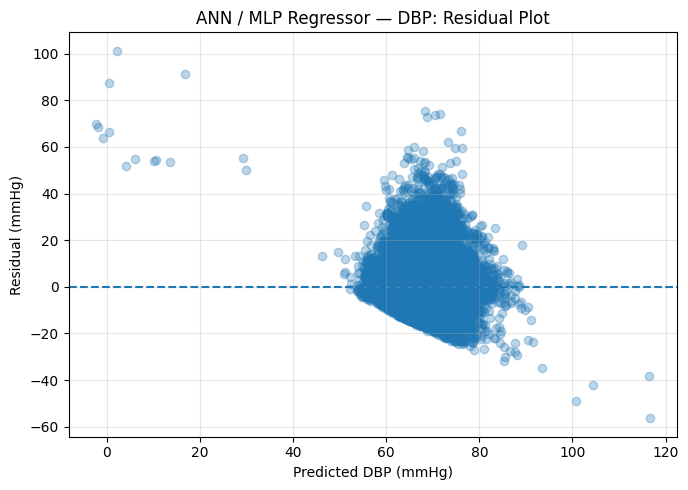

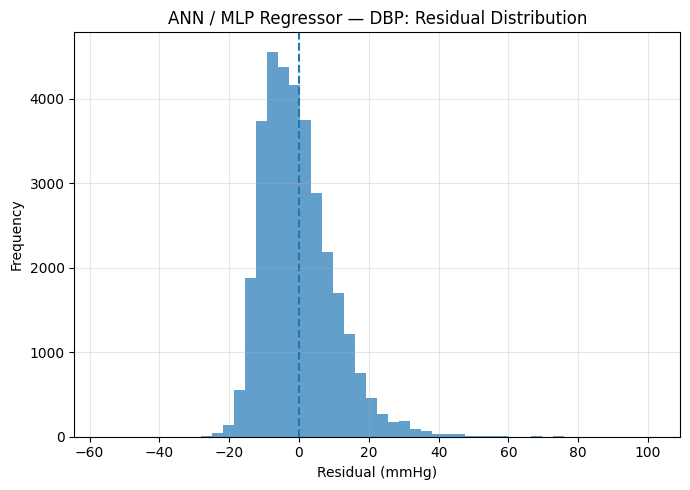

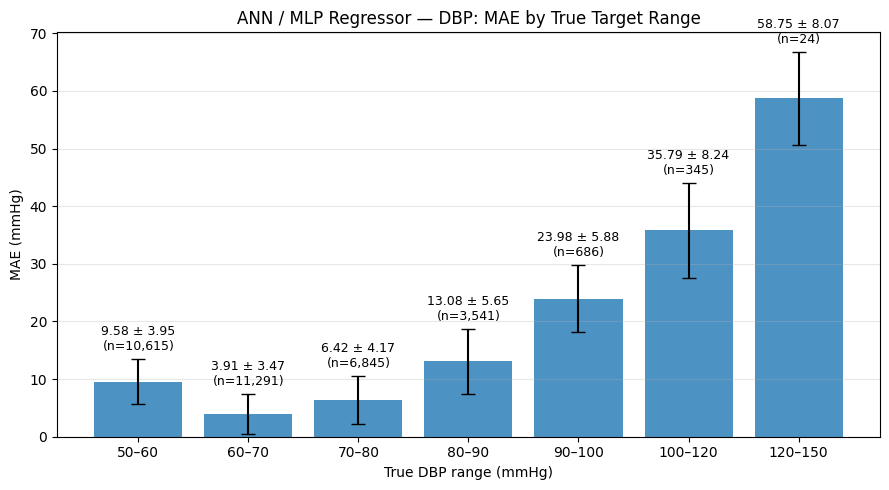

In [31]:
ann_model, y_test_pred = ann(
    X_dev,
    y_dev,
    X_test,
    y_test,
    TARGET
)

Processed 10,000 / 2,928,374
Processed 20,000 / 2,928,374
Processed 30,000 / 2,928,374
Processed 40,000 / 2,928,374
Processed 50,000 / 2,928,374
Processed 60,000 / 2,928,374
Processed 70,000 / 2,928,374
Processed 80,000 / 2,928,374
Processed 90,000 / 2,928,374
Processed 100,000 / 2,928,374
Processed 110,000 / 2,928,374
Processed 120,000 / 2,928,374
Processed 130,000 / 2,928,374
Processed 140,000 / 2,928,374
Processed 150,000 / 2,928,374
Processed 160,000 / 2,928,374
Processed 170,000 / 2,928,374
Processed 180,000 / 2,928,374
Processed 190,000 / 2,928,374
Processed 200,000 / 2,928,374
Processed 210,000 / 2,928,374
Processed 220,000 / 2,928,374
Processed 230,000 / 2,928,374
Processed 240,000 / 2,928,374
Processed 250,000 / 2,928,374
Processed 260,000 / 2,928,374
Processed 270,000 / 2,928,374
Processed 280,000 / 2,928,374
Processed 290,000 / 2,928,374
Processed 300,000 / 2,928,374
Processed 310,000 / 2,928,374
Processed 320,000 / 2,928,374
Processed 330,000 / 2,928,374
Processed 340,000 /

/data1/yashvi_bhuva/BP_estimation_using_PPG/experiments/ML/non_fiducial_features/8sec_0overlap/mrmr/../../regression.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/data1/yashvi_bhuva/BP_estimation_using_PPG/UCI/venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


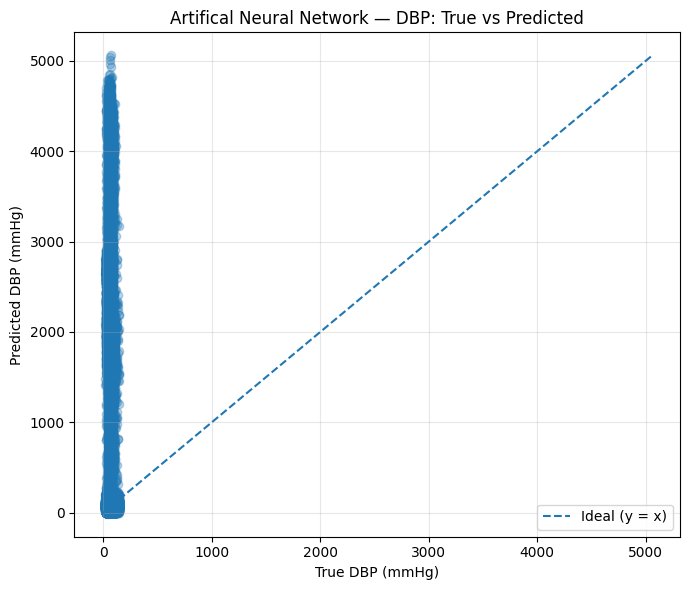

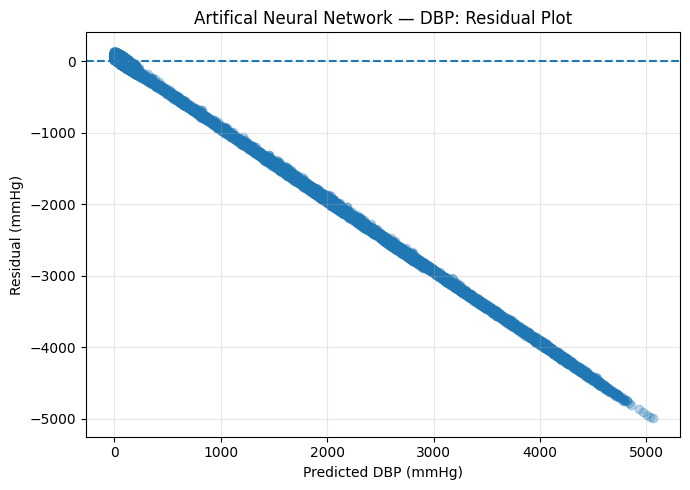

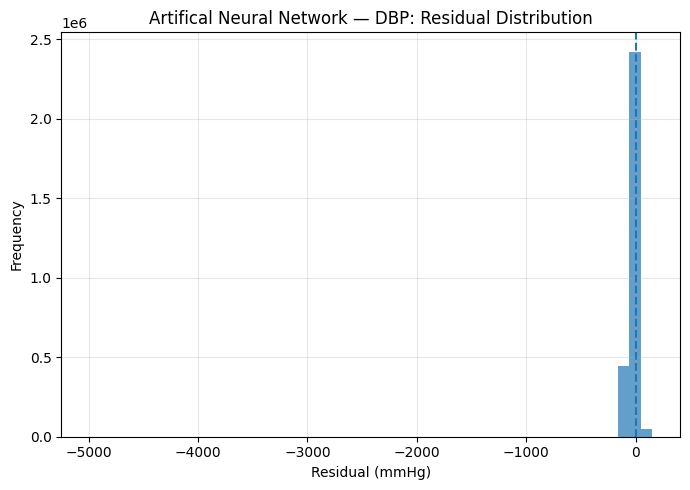

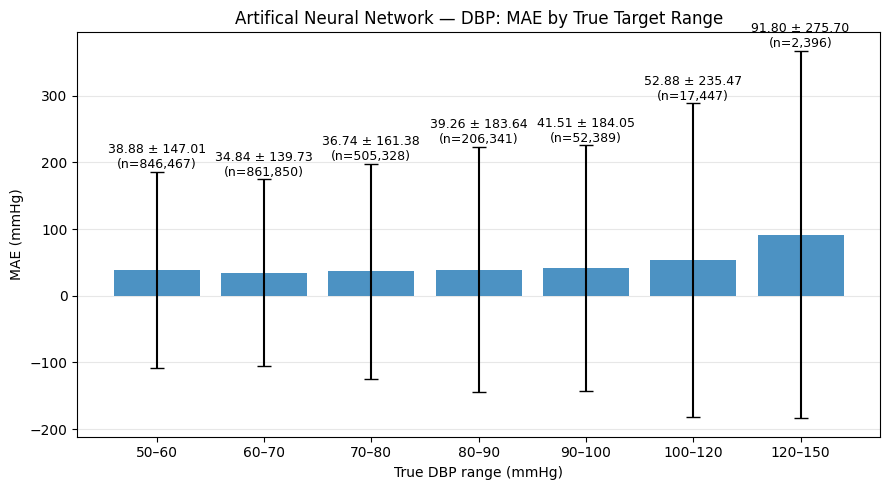

In [32]:
y_pred_vitaldb = predict_ann_in_batches(
    ann_model,
    X_test_vital,
y_test_vital,
    target_name=TARGET,
    model_name="Artifical Neural Network",
    batch_size=10000
)